# Week 6 Student Worksheet: Spatial Prediction Shootout

## Traditional Stats vs. Machine Learning: Filling the Gaps

> *"Kriging tells you where it's uncertain. ML just says 'trust me.'"*

### Today's Mission

Transform Week 5's discrete rainfall stations into **continuous rainfall surfaces** using **two fundamentally different approaches**:

1. **Kriging (Statistical)** — uses spatial correlation + provides uncertainty
2. **Random Forest (ML)** — uses data patterns + easily adds features

Then compare them head-to-head with two simpler methods (Nearest Neighbor, IDW) and determine which gives the Commander more actionable intelligence.

> Fill in the code cells marked with `# YOUR CODE HERE`. Use AI tools strategically — but understand every line you write.

In [1]:
# Install required packages (run once)
%pip install pykrige scikit-learn rasterio rasterstats --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---

## Cell [1]: Environment Setup & Data Loading (Slide 2)

Load the Fung-wong typhoon data and filter to the study area. Reuse your Week 5 `parse_rainfall_json()` function.

**AI Prompt Suggestion**:
```
I need to load fungwong_202511.json and parse it into a GeoDataFrame using
my Week 5 parse_rainfall_json() function. Then filter to 花蓮縣 and 宜蘭縣,
remove -998/zero rain stations, and convert to EPSG:3826.
Show me the top 5 stations by rain_1hr.
```

In [3]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
from shapely.geometry import Point
warnings.filterwarnings('ignore')

# YOUR CODE HERE:
# 1. Define normalize_cwa_json() and parse_rainfall_json() (copy from Week 5)
# 2. Load 'data/scenarios/fungwong_202511.json'
# 3. Parse into GeoDataFrame
# 4. Filter to 花蓮縣 + 宜蘭縣
# 5. Remove stations with rain_1hr <= 0
# 6. Convert to EPSG:3826


# Extract coordinate arrays for Kriging / ML
# x = study_rain_3826.geometry.x.values  # Easting (meters)
# y = study_rain_3826.geometry.y.values  # Northing (meters)
# z = study_rain_3826['rain_1hr'].values

# print(f"Study area stations (rain > 0): {len(study_rain_3826)}")
# print(f"CRS: {study_rain_3826.crs}")
# print(f"\nTop 5 stations:")
# print(study_rain_3826.nlargest(5, 'rain_1hr')[['station_name', 'county', 'rain_1hr']].to_string(index=False))

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
from shapely.geometry import Point
warnings.filterwarnings('ignore')


def normalize_cwa_json(raw):
    """
    將不同來源的 CWA / converted JSON 統一為 station list。

    支援：
    1. raw["records"]["Station"]
    2. raw["cwaopendata"]["dataset"]["Station"]
    """
    if not isinstance(raw, dict):
        raise ValueError("輸入資料必須是 dict（JSON 解析後物件）。")

    # Case 1: CWA API JSON / CoLife-converted JSON
    if "records" in raw and isinstance(raw["records"], dict) and "Station" in raw["records"]:
        stations = raw["records"]["Station"]
        return stations if isinstance(stations, list) else [stations]

    # Case 2: XML-converted JSON
    if (
        "cwaopendata" in raw
        and isinstance(raw["cwaopendata"], dict)
        and "dataset" in raw["cwaopendata"]
        and isinstance(raw["cwaopendata"]["dataset"], dict)
        and "Station" in raw["cwaopendata"]["dataset"]
    ):
        stations = raw["cwaopendata"]["dataset"]["Station"]
        return stations if isinstance(stations, list) else [stations]

    raise ValueError("找不到 station list，JSON 格式不支援。")


def _safe_float(v):
    """安全轉成 float，失敗則回傳 None。"""
    try:
        if v in [None, "", " ", "-998", -998]:
            return None
        return float(v)
    except (TypeError, ValueError):
        return None


def _extract_wgs84_coords(station):
    """
    從 station dict 中萃取 WGS84 經緯度。
    優先使用 WGS84，避免誤用 TWD67 / TWD97。
    """
    geo_info = station.get("GeoInfo", {}) if isinstance(station.get("GeoInfo", {}), dict) else {}

    # 常見格式：GeoInfo -> Coordinates 為 list
    coords = geo_info.get("Coordinates", [])
    if isinstance(coords, dict):
        coords = [coords]

    if isinstance(coords, list):
        # 先找 WGS84
        for c in coords:
            if not isinstance(c, dict):
                continue
            coord_name = str(c.get("CoordinateName", "")).upper()
            if "WGS84" in coord_name:
                lon = _safe_float(c.get("StationLongitude"))
                lat = _safe_float(c.get("StationLatitude"))
                if lon is not None and lat is not None:
                    return lon, lat

        # 若沒有明確 WGS84，再退而求其次找看起來像經緯度的座標
        for c in coords:
            if not isinstance(c, dict):
                continue
            lon = _safe_float(c.get("StationLongitude"))
            lat = _safe_float(c.get("StationLatitude"))
            if lon is not None and lat is not None and abs(lon) <= 180 and abs(lat) <= 90:
                return lon, lat

    # 備援：有些資料可能直接放在 station 或 GeoInfo
    fallback_lon_keys = ["StationLongitude", "longitude", "lon"]
    fallback_lat_keys = ["StationLatitude", "latitude", "lat"]

    for lon_key in fallback_lon_keys:
        for lat_key in fallback_lat_keys:
            lon = _safe_float(station.get(lon_key))
            lat = _safe_float(station.get(lat_key))
            if lon is not None and lat is not None and abs(lon) <= 180 and abs(lat) <= 90:
                return lon, lat

            lon = _safe_float(geo_info.get(lon_key))
            lat = _safe_float(geo_info.get(lat_key))
            if lon is not None and lat is not None and abs(lon) <= 180 and abs(lat) <= 90:
                return lon, lat

    return None, None


def _extract_rain_values(station):
    """
    從 station dict 中萃取雨量欄位。
    回傳：
    rain_10min, rain_1hr, rain_3hr, rain_6hr, rain_12hr, rain_24hr
    """
    rainfall = station.get("RainfallElement", {})
    if not isinstance(rainfall, dict):
        rainfall = {}

    def get_precip(block_name):
        block = rainfall.get(block_name, {})
        if isinstance(block, dict):
            return _safe_float(block.get("Precipitation"))
        return None

    rain_10min = get_precip("Past10Min")
    rain_1hr   = get_precip("Past1hr")
    rain_3hr   = get_precip("Past3hr")
    rain_6hr   = get_precip("Past6hr")
    rain_12hr  = get_precip("Past12hr")
    rain_24hr  = get_precip("Past24hr")

    return rain_10min, rain_1hr, rain_3hr, rain_6hr, rain_12hr, rain_24hr


def parse_rainfall_json(data):
    """
    將原始雨量 JSON 解析為 GeoDataFrame (EPSG:4326)

    輸出欄位：
    - StationName
    - StationId
    - CountyName
    - TownName
    - lon
    - lat
    - rain_10min
    - rain_1hr
    - rain_3hr
    - rain_6hr
    - rain_12hr
    - rain_24hr
    - geometry
    """
    stations = normalize_cwa_json(data)
    rows = []

    for station in stations:
        if not isinstance(station, dict):
            continue

        station_name = station.get("StationName", station.get("stationName"))
        station_id = station.get("StationId", station.get("stationId"))

        geo_info = station.get("GeoInfo", {}) if isinstance(station.get("GeoInfo", {}), dict) else {}
        county_name = geo_info.get("CountyName")
        town_name = geo_info.get("TownName")

        lon, lat = _extract_wgs84_coords(station)
        rain_10min, rain_1hr, rain_3hr, rain_6hr, rain_12hr, rain_24hr = _extract_rain_values(station)

        if lon is None or lat is None:
            continue

        rows.append({
            "StationName": station_name,
            "StationId": station_id,
            "CountyName": county_name,
            "TownName": town_name,
            "lon": lon,
            "lat": lat,
            "rain_10min": 0.0 if rain_10min is None else rain_10min,
            "rain_1hr": 0.0 if rain_1hr is None else rain_1hr,
            "rain_3hr": 0.0 if rain_3hr is None else rain_3hr,
            "rain_6hr": 0.0 if rain_6hr is None else rain_6hr,
            "rain_12hr": 0.0 if rain_12hr is None else rain_12hr,
            "rain_24hr": 0.0 if rain_24hr is None else rain_24hr
        })

    df = pd.DataFrame(rows)

    if df.empty:
        print("Warning: 沒有成功解析任何雨量站。")
        return gpd.GeoDataFrame(df, geometry=[], crs="EPSG:4326")

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326"
    )

    return gdf


# 1. Load JSON
with open("data/scenarios/fungwong_202511.json", "r", encoding="utf-8") as f:
    raw_data = json.load(f)

# 2. Parse into GeoDataFrame
rain_gdf = parse_rainfall_json(raw_data)

# 3. Filter to 花蓮縣 + 宜蘭縣
study_rain = rain_gdf[rain_gdf["CountyName"].isin(["花蓮縣", "宜蘭縣"])].copy()

# 4. Remove stations with rain_1hr <= 0
study_rain = study_rain[study_rain["rain_1hr"] > 0].copy()

# 5. Convert to EPSG:3826
study_rain_3826 = study_rain.to_crs(epsg=3826)

# 6. Rename columns for later convenience (optional but matches notebook print block)
study_rain_3826 = study_rain_3826.rename(columns={
    "StationName": "station_name",
    "StationId": "station_id",
    "CountyName": "county",
    "TownName": "town"
})

# Extract coordinate arrays for Kriging / ML
x = study_rain_3826.geometry.x.values  # Easting (meters)
y = study_rain_3826.geometry.y.values  # Northing (meters)
z = study_rain_3826["rain_1hr"].values

print(f"Study area stations (rain > 0): {len(study_rain_3826)}")
print(f"CRS: {study_rain_3826.crs}")
print(f"\nTop 5 stations:")
print(study_rain_3826.nlargest(5, "rain_1hr")[["station_name", "county", "rain_1hr"]].to_string(index=False))

Study area stations (rain > 0): 89
CRS: EPSG:3826

Top 5 stations:
station_name county  rain_1hr
          蘇澳    宜蘭縣     130.5
     國五S047K    宜蘭縣      80.5
          五結    宜蘭縣      71.0
          冬山    宜蘭縣      61.5
     國五S041K    宜蘭縣      46.0


---

## Cell [2a]: Variogram — First Attempt (Naive)

Try running Kriging directly on the raw rainfall data. **Don't worry if it looks bad — that's the point.**

**Key Concepts** (will make sense after you see the result):
- **Nugget**: How noisy is each measurement?
- **Sill**: What's the maximum difference between stations?
- **Range**: How far apart do stations need to be before they stop "knowing about each other"?

**CRS Warning**: The x, y arrays MUST be in EPSG:3826 (meters). Using lat/lon will give wrong results.

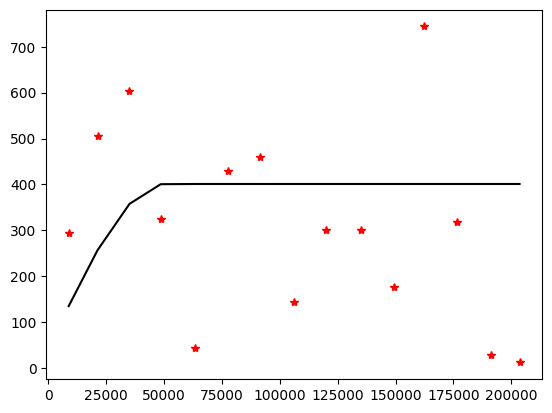

Sill:   360.8
Range:  50000 m (50.0 km)
Nugget: 40.1

⚠️ Look at the plot — do the dots follow the curve?


In [4]:
from pykrige.ok import OrdinaryKriging

# 🔴 First attempt: run Kriging on raw rainfall data
# YOUR CODE HERE:
# 1. Create OrdinaryKriging with raw z values
#    Use variogram_model='spherical', verbose=False, enable_plotting=True, nlags=15
# 2. Provide initial parameters to help the optimizer:
#    sill = z.var(), range = 50000, nugget = z.var() * 0.1

# initial_sill = float(z.var())
# initial_range = 50000.0
# initial_nugget = float(z.var() * 0.1)

# OK_naive = OrdinaryKriging(x, y, z, variogram_model='spherical',
#                             verbose=False, enable_plotting=True, nlags=15,
#                             variogram_parameters={'sill': initial_sill,
#                                                   'range': initial_range,
#                                                   'nugget': initial_nugget})

# params = OK_naive.variogram_model_parameters
# print(f"Sill:   {params[0]:.1f}")
# print(f"Range:  {params[1]:.0f} m ({params[1]/1000:.1f} km)")
# print(f"Nugget: {params[2]:.1f}")
# print("\n⚠️ Look at the plot — do the dots follow the curve?")


from pykrige.ok import OrdinaryKriging

# 🔴 First attempt: run Kriging on raw rainfall data

# 1. Provide initial parameters to help the optimizer
initial_sill = float(z.var())
initial_range = 50000.0
initial_nugget = float(z.var() * 0.1)

# 2. Create OrdinaryKriging with raw z values
OK_naive = OrdinaryKriging(
    x, y, z,
    variogram_model='spherical',
    verbose=False,
    enable_plotting=True,
    nlags=15,
    variogram_parameters={
        'sill': initial_sill,
        'range': initial_range,
        'nugget': initial_nugget
    }
)

# 3. Read fitted variogram parameters
params = OK_naive.variogram_model_parameters
print(f"Sill:   {params[0]:.1f}")
print(f"Range:  {params[1]:.0f} m ({params[1]/1000:.1f} km)")
print(f"Nugget: {params[2]:.1f}")

print("\n⚠️ Look at the plot — do the dots follow the curve?")

## Cell [2b]: Why Did It Fail? — Look at the Histogram

The variogram looked bad. Before blaming the tool, **look at your data**.

Plot a histogram of the rainfall values. What do you see?

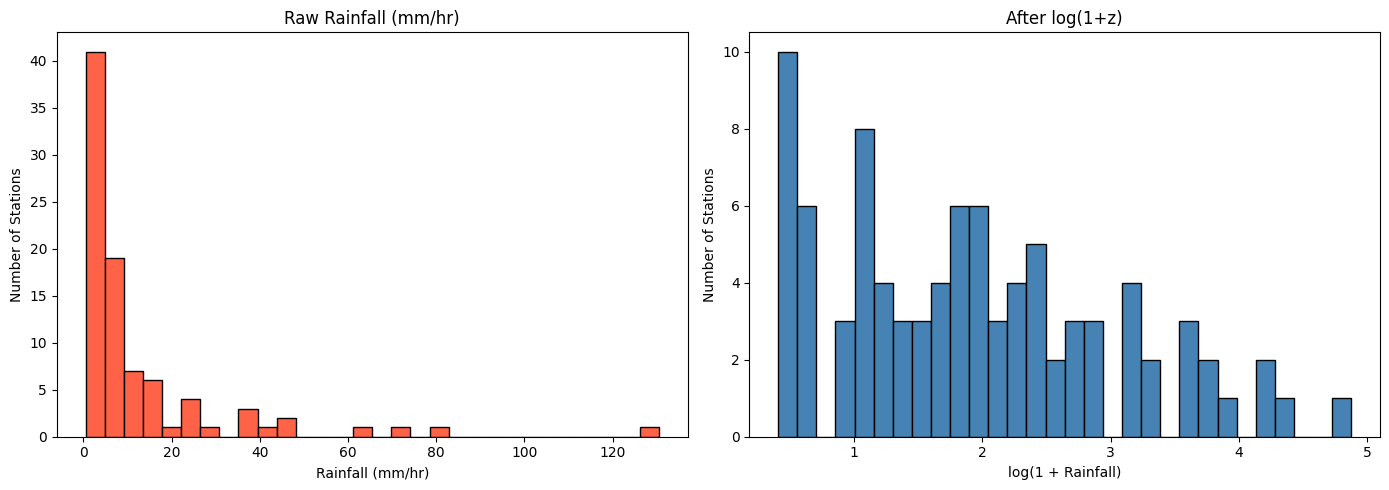

Left: most stations < 10 mm, but a few are 50-130 mm.
Those extreme values mess up the variogram.
Right: after log-transform, the values are more balanced.


In [5]:
# YOUR CODE HERE:
# 1. Plot a histogram of z (raw rainfall)
# 2. Plot a histogram of np.log1p(z) (log-transformed)
# 3. Compare: which one looks more "balanced"?

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# axes[0].hist(z, bins=30, color='tomato', edgecolor='black')
# axes[0].set_title('Raw Rainfall (mm/hr)')
# axes[0].set_xlabel('Rainfall (mm/hr)')

# z_log = np.log1p(z)
# axes[1].hist(z_log, bins=30, color='steelblue', edgecolor='black')
# axes[1].set_title('After log(1+z)')
# axes[1].set_xlabel('log(1 + Rainfall)')
# plt.tight_layout()
# plt.show()

# print("Left: most stations < 10 mm, but a few are 50-130 mm.")
# print("Those extreme values mess up the variogram.")
# print("Right: after log-transform, the values are more balanced.")

# 1. Plot a histogram of z (raw rainfall)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(z, bins=30, color='tomato', edgecolor='black')
axes[0].set_title('Raw Rainfall (mm/hr)')
axes[0].set_xlabel('Rainfall (mm/hr)')
axes[0].set_ylabel('Number of Stations')

# 2. Plot a histogram of np.log1p(z) (log-transformed)
z_log = np.log1p(z)

axes[1].hist(z_log, bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('After log(1+z)')
axes[1].set_xlabel('log(1 + Rainfall)')
axes[1].set_ylabel('Number of Stations')

plt.tight_layout()
plt.show()

# 3. Compare: which one looks more "balanced"?
print("Left: most stations < 10 mm, but a few are 50-130 mm.")
print("Those extreme values mess up the variogram.")
print("Right: after log-transform, the values are more balanced.")


## Cell [2c]: Variogram — Second Attempt (with Log-Transform)

Now redo the variogram using the log-transformed data. Compare this plot with Cell [2a] — it should be much better.

**Rule of thumb**: If your histogram has a long tail to the right, apply `np.log1p(z)` before Kriging, then use `np.expm1()` to convert back after prediction.

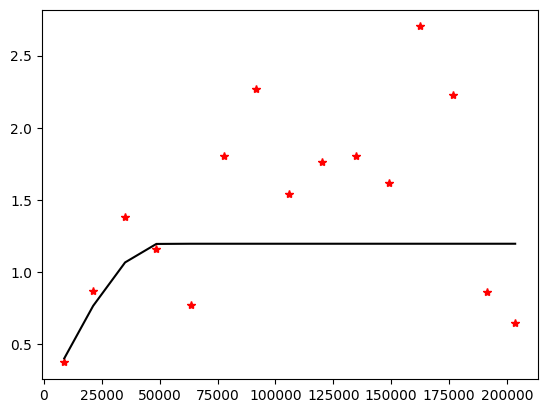

Sill:   1.076
Range:  50000 m (50.0 km)
Nugget: 0.120

✅ Compare with Cell [2a] — the dots should follow the curve now.


In [7]:
# 🟢 Second attempt: Kriging on log-transformed data
# YOUR CODE HERE:
# 1. z_log = np.log1p(z)  (already computed above)
# 2. Create OrdinaryKriging with z_log (not z!)
# 3. Use initial parameters based on z_log.var()

# initial_sill = float(z_log.var())
# initial_range = 50000.0
# initial_nugget = float(z_log.var() * 0.1)

# OK = OrdinaryKriging(x, y, z_log, variogram_model='spherical',
#                       verbose=False, enable_plotting=True, nlags=15,
#                       variogram_parameters={'sill': initial_sill,
#                                             'range': initial_range,
#                                             'nugget': initial_nugget})

# params = OK.variogram_model_parameters
# print(f"Sill:   {params[0]:.3f}")
# print(f"Range:  {params[1]:.0f} m ({params[1]/1000:.1f} km)")
# print(f"Nugget: {params[2]:.3f}")
# print("\n✅ Compare with Cell [2a] — the dots should follow the curve now.")

# 🟢 Second attempt: Kriging on log-transformed data

# 1. z_log = np.log1p(z)  (already computed above)

# 2. Use initial parameters based on z_log.var()
initial_sill = float(z_log.var())
initial_range = 50000.0
initial_nugget = float(z_log.var() * 0.1)

# 3. Create OrdinaryKriging with z_log (not z!)
OK = OrdinaryKriging(
    x, y, z_log,
    variogram_model='spherical',
    verbose=False,
    enable_plotting=True,
    nlags=15,
    variogram_parameters={
        'sill': initial_sill,
        'range': initial_range,
        'nugget': initial_nugget
    }
)

params = OK.variogram_model_parameters
print(f"Sill:   {params[0]:.3f}")
print(f"Range:  {params[1]:.0f} m ({params[1]/1000:.1f} km)")
print(f"Nugget: {params[2]:.3f}")
print("\n✅ Compare with Cell [2a] — the dots should follow the curve now.")

## Cell [2d]: Which Variogram Fits Best? — Range & Model Comparison (Slide 7)

Compare variograms **one variable at a time** — this is how scientists isolate effects:

- **Figure 1**: Fix model = **Spherical**, vary Range (50km, 25km, 15km) → what does Range do?
- **Figure 2**: Fix model = **Exponential**, vary Range (50km, 25km, 15km) → same exercise
- **Then compare**: same Range, different model → what does the model choice do?

**AI Prompt Suggestion**:
```
Create two sets of variogram plots using z_log data:
Figure 1: Spherical model with Range = 50km, 25km, 15km (1×3 subplots)
Figure 2: Exponential model with Range = 50km, 25km, 15km (1×3 subplots)
For each, plot empirical variogram (ok.lags vs ok.semivariance) as red dots
and the fitted model curve as a black line.
Compute SSE for each config and print a summary table.
Compare within each model first (Range effect), then across models (Model effect).
```

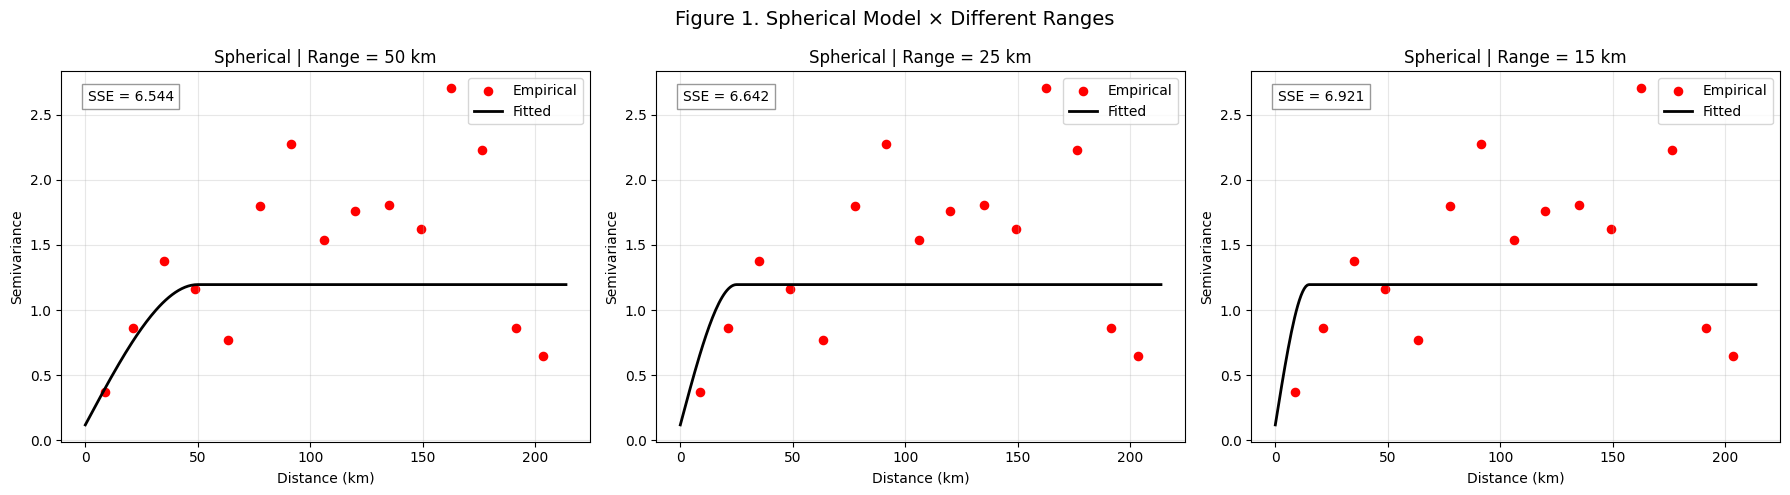

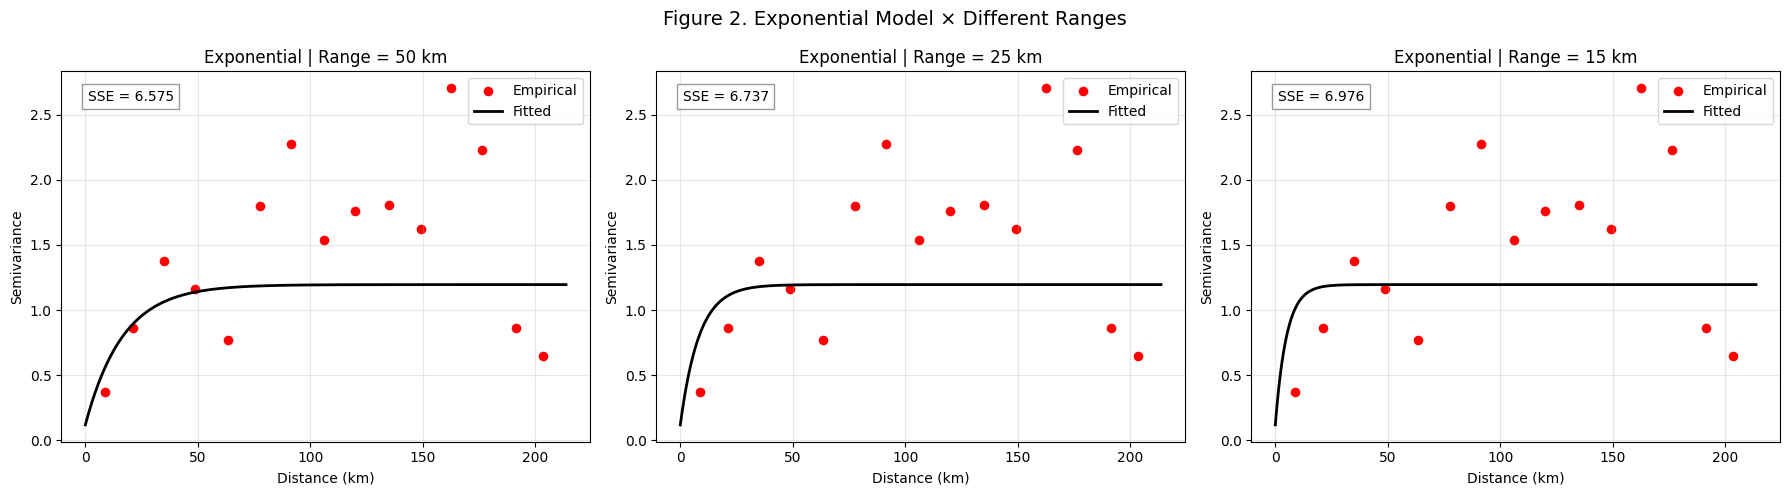

=== Summary Table ===


,model,range_km,sill,range_m,nugget,SSE
0,exponential,15,1.076153,15000.0,0.119573,6.976205
1,exponential,25,1.076153,25000.0,0.119573,6.737273
2,exponential,50,1.076153,50000.0,0.119573,6.575366
3,spherical,15,1.076153,15000.0,0.119573,6.921389
4,spherical,25,1.076153,25000.0,0.119573,6.642205
5,spherical,50,1.076153,50000.0,0.119573,6.544171



=== Within Spherical: Range Effect ===


,model,range_km,sill,range_m,nugget,SSE
5,spherical,50,1.076153,50000.0,0.119573,6.544171
4,spherical,25,1.076153,25000.0,0.119573,6.642205
3,spherical,15,1.076153,15000.0,0.119573,6.921389


Best Spherical fit by SSE: Range = 50 km, SSE = 6.544

=== Within Exponential: Range Effect ===


...


Range = 25 km


,model,range_km,sill,range_m,nugget,SSE
4,spherical,25,1.076153,25000.0,0.119573,6.642205
1,exponential,25,1.076153,25000.0,0.119573,6.737273



Range = 15 km


,model,range_km,sill,range_m,nugget,SSE
3,spherical,15,1.076153,15000.0,0.119573,6.921389
0,exponential,15,1.076153,15000.0,0.119573,6.976205



💡 Questions:
1. Within Spherical, which Range gives the best fit?
2. Within Exponential, which Range gives the best fit?
3. At the same Range, does model choice matter much?


In [8]:
# YOUR CODE HERE:
# 1. Define ranges: [50000, 25000, 15000]
# 2. Figure 1: Spherical × 3 Ranges (1×3 subplot)
#    For each: create OrdinaryKriging, plot lags vs semivariance (red dots),
#    plot fitted curve (black line), compute SSE
# 3. Figure 2: Exponential × 3 Ranges (1×3 subplot)
#    Same as above but with variogram_model='exponential'
# 4. Print summary table:
#    - Compare within Spherical (Range effect)
#    - Compare within Exponential (Range effect)
#    - Compare Spherical vs Exponential at same Range (Model effect)

# ranges_km = [50, 25, 15]

# ─── Figure 1: Spherical ───
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# for ax, rkm in zip(axes, ranges_km):
#     ok_test = OrdinaryKriging(x, y, z_log, variogram_model='spherical', ...)
#     ax.scatter(ok_test.lags/1000, ok_test.semivariance, c='red', ...)
#     # plot fitted curve ...

# ─── Figure 2: Exponential ───
# (same structure)

# 💡 Questions:
#   1. Within Spherical, which Range gives the best fit?
#   2. Within Exponential, which Range gives the best fit?
#   3. At the same Range, does model choice matter much?


# 1. Define ranges: [50000, 25000, 15000]
ranges_km = [50, 25, 15]
ranges_m = [r * 1000 for r in ranges_km]

results = []

def plot_variogram_comparison(model_name, axes):
    for ax, rkm, rm in zip(axes, ranges_km, ranges_m):
        sill = float(z_log.var())
        nugget = float(z_log.var() * 0.1)

        ok_test = OrdinaryKriging(
            x, y, z_log,
            variogram_model=model_name,
            verbose=False,
            enable_plotting=False,
            nlags=15,
            variogram_parameters={
                'sill': sill,
                'range': float(rm),
                'nugget': nugget
            }
        )

        # empirical variogram
        lags_km = ok_test.lags / 1000.0
        empirical = ok_test.semivariance

        # fitted model curve
        params = ok_test.variogram_model_parameters
        dist_line = np.linspace(0, np.max(ok_test.lags) * 1.05, 300)
        model_line = ok_test.variogram_function(params, dist_line)

        # SSE
        fitted_at_lags = ok_test.variogram_function(params, ok_test.lags)
        sse = float(np.sum((empirical - fitted_at_lags) ** 2))

        # plot
        ax.scatter(lags_km, empirical, c='red', s=35, label='Empirical')
        ax.plot(dist_line / 1000.0, model_line, c='black', linewidth=2, label='Fitted')
        ax.set_title(f"{model_name.capitalize()} | Range = {rkm} km")
        ax.set_xlabel("Distance (km)")
        ax.set_ylabel("Semivariance")
        ax.grid(alpha=0.3)
        ax.legend()
        ax.text(
            0.05, 0.95,
            f"SSE = {sse:.3f}",
            transform=ax.transAxes,
            ha='left', va='top',
            fontsize=10,
            bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8)
        )

        results.append({
            "model": model_name,
            "range_km": rkm,
            "sill": float(params[0]),
            "range_m": float(params[1]),
            "nugget": float(params[2]),
            "SSE": sse
        })


# 2. Figure 1: Spherical × 3 Ranges (1×3 subplot)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_variogram_comparison("spherical", axes)
fig.suptitle("Figure 1. Spherical Model × Different Ranges", fontsize=14)
plt.tight_layout()
plt.show()

# 3. Figure 2: Exponential × 3 Ranges (1×3 subplot)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_variogram_comparison("exponential", axes)
fig.suptitle("Figure 2. Exponential Model × Different Ranges", fontsize=14)
plt.tight_layout()
plt.show()

# 4. Print summary table
summary_df = pd.DataFrame(results)
summary_df = summary_df[["model", "range_km", "sill", "range_m", "nugget", "SSE"]]
summary_df = summary_df.sort_values(["model", "range_km"]).reset_index(drop=True)

print("=== Summary Table ===")
display(summary_df)

print("\n=== Within Spherical: Range Effect ===")
spherical_df = summary_df[summary_df["model"] == "spherical"].sort_values("SSE")
display(spherical_df)
best_spherical = spherical_df.iloc[0]
print(f"Best Spherical fit by SSE: Range = {int(best_spherical['range_km'])} km, SSE = {best_spherical['SSE']:.3f}")

print("\n=== Within Exponential: Range Effect ===")
exponential_df = summary_df[summary_df["model"] == "exponential"].sort_values("SSE")
display(exponential_df)
best_exponential = exponential_df.iloc[0]
print(f"Best Exponential fit by SSE: Range = {int(best_exponential['range_km'])} km, SSE = {best_exponential['SSE']:.3f}")

print("\n=== Same Range: Model Effect ===")
for rkm in ranges_km:
    subset = summary_df[summary_df["range_km"] == rkm].sort_values("SSE")
    print(f"\nRange = {rkm} km")
    display(subset)

print("\n💡 Questions:")
print("1. Within Spherical, which Range gives the best fit?")
print("2. Within Exponential, which Range gives the best fit?")
print("3. At the same Range, does model choice matter much?")

## Cell [3]: Define the Interpolation Grid & Run Kriging (Slide 8)

Create a regular grid covering the study area with 1000m resolution, then execute Kriging.

**Think about**:
- What units is the grid in? (Hint: same as your CRS = meters)
- Why add a buffer around the station extent?

**Important**: Kriging runs in log-space. After prediction, **back-transform** with `np.expm1()` to get rainfall in mm/hr.

In [10]:
import time

# YOUR CODE HERE:
# 1. Calculate grid extent from x, y arrays (with 5km buffer)
# 2. Create grid_x and grid_y using np.arange with 1000m step
# 3. Execute Kriging in log-space: z_kriging_log, ss_kriging_log = OK.execute('grid', grid_x, grid_y)
# 4. Back-transform: z_kriging = np.expm1(z_kriging_log)

buffer_m = 5000
resolution = 1000  # meters — use 500 for finer resolution (slower)

# x_min = x.min() - buffer_m
# x_max = x.max() + buffer_m
# y_min = y.min() - buffer_m
# y_max = y.max() + buffer_m
# grid_x = np.arange(x_min, x_max, resolution)
# grid_y = np.arange(y_min, y_max, resolution)

# print(f"Grid: {len(grid_x)}×{len(grid_y)} = {len(grid_x)*len(grid_y):,} points @ {resolution}m")

# t0 = time.time()
# z_kriging_log, ss_kriging_log = OK.execute('grid', grid_x, grid_y)
# print(f"✓ Kriging (log-space) done in {time.time()-t0:.1f}s")

# # Back-transform to real rainfall (mm/hr)
# z_kriging = np.expm1(z_kriging_log)
# z_kriging[z_kriging < 0] = 0
# ss_kriging = ss_kriging_log  # keep log-space variance for Sigma Map

# print(f"  z range (mm/hr): {np.nanmin(z_kriging):.1f} - {np.nanmax(z_kriging):.1f}")

import time

# 1. Calculate grid extent from x, y arrays (with 5km buffer)
buffer_m = 5000
resolution = 1000  # meters — use 500 for finer resolution (slower)

x_min = x.min() - buffer_m
x_max = x.max() + buffer_m
y_min = y.min() - buffer_m
y_max = y.max() + buffer_m

# 2. Create grid_x and grid_y using np.arange with 1000m step
grid_x = np.arange(x_min, x_max, resolution)
grid_y = np.arange(y_min, y_max, resolution)

print(f"Grid: {len(grid_x)}×{len(grid_y)} = {len(grid_x)*len(grid_y):,} points @ {resolution}m")

# 3. Execute Kriging in log-space
t0 = time.time()
z_kriging_log, ss_kriging_log = OK.execute('grid', grid_x, grid_y)
print(f"✓ Kriging (log-space) done in {time.time()-t0:.1f}s")

# 4. Back-transform to real rainfall (mm/hr)
z_kriging = np.expm1(z_kriging_log)
z_kriging[z_kriging < 0] = 0

# keep log-space variance for Sigma Map
ss_kriging = ss_kriging_log

print(f"  z range (mm/hr): {np.nanmin(z_kriging):.1f} - {np.nanmax(z_kriging):.1f}")

Grid: 87×211 = 18,357 points @ 1000m
✓ Kriging (log-space) done in 0.1s
  z range (mm/hr): 0.5 - 71.2


---

## Cell [4]: Machine Learning — Random Forest Prediction (Slide 9)

**Captain's Log**: Treating coordinates as input features. ML learns `f(easting, northing) → rainfall`. Simple, but no uncertainty map.

**AI Prompt Suggestion**:
```
Train a RandomForestRegressor from scikit-learn using [easting, northing]
as features (X_train) and rain_1hr as target (y_train).
Use n_estimators=200, min_samples_leaf=3, random_state=42.
Then predict on the same grid as Kriging.
```

In [11]:
from sklearn.ensemble import RandomForestRegressor

# YOUR CODE HERE:
# 1. Prepare features: X_train = np.column_stack([x, y])
# 2. Train RandomForestRegressor
# 3. Create meshgrid from grid_x, grid_y
# 4. Predict on the grid

# X_train = np.column_stack([x, y])
# y_train = z

# rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=3, random_state=42)
# rf.fit(X_train, y_train)
# print(f"RF Training R²: {rf.score(X_train, y_train):.3f}")

# grid_xx, grid_yy = np.meshgrid(grid_x, grid_y)
# X_grid = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])

# t0 = time.time()
# z_rf = rf.predict(X_grid).reshape(grid_xx.shape)
# print(f"✓ Random Forest done in {time.time()-t0:.1f}s")
# print(f"  z range: {z_rf.min():.1f} - {z_rf.max():.1f} mm/hr")

from sklearn.ensemble import RandomForestRegressor

# 1. Prepare features
X_train = np.column_stack([x, y])
y_train = z

# 2. Train RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=3,
    random_state=42
)
rf.fit(X_train, y_train)
print(f"RF Training R²: {rf.score(X_train, y_train):.3f}")

# 3. Create meshgrid from grid_x, grid_y
grid_xx, grid_yy = np.meshgrid(grid_x, grid_y)
X_grid = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])

# 4. Predict on the grid
t0 = time.time()
z_rf = rf.predict(X_grid).reshape(grid_xx.shape)
print(f"✓ Random Forest done in {time.time()-t0:.1f}s")
print(f"  z range: {z_rf.min():.1f} - {z_rf.max():.1f} mm/hr")


RF Training R²: 0.775
✓ Random Forest done in 0.0s
  z range: 0.6 - 62.6 mm/hr


## Cell [5]: ML Glass Box — Feature Importance (Slide 11)

**Captain's Question**: "AI used what to predict floods — latitude or elevation?"

Even though ML is a "black box", we can peek inside with `.feature_importances_`.

In [12]:
# YOUR CODE HERE:
# 1. Print rf.feature_importances_
# 2. Interpret: which dimension matters more for typhoon rainfall?

# importances = rf.feature_importances_
# print("Feature Importance:")
# print(f"  Easting (X):  {importances[0]:.3f}")
# print(f"  Northing (Y): {importances[1]:.3f}")
# print(f"\nThe model relies mostly on {'easting' if importances[0] > importances[1] else 'northing'}.")
# print("Think: does this make physical sense for Typhoon Fung-wong?")

# 1. Print rf.feature_importances_
importances = rf.feature_importances_

print("Feature Importance:")
print(f"  Easting (X):  {importances[0]:.3f}")
print(f"  Northing (Y): {importances[1]:.3f}")

# 2. Interpret: which dimension matters more for typhoon rainfall?
print(f"\nThe model relies mostly on {'easting' if importances[0] > importances[1] else 'northing'}.")
print("Think: does this make physical sense for Typhoon Fung-wong?")

Feature Importance:
  Easting (X):  0.485
  Northing (Y): 0.515

The model relies mostly on northing.
Think: does this make physical sense for Typhoon Fung-wong?


---

## ⏸️ Lab 1: The Four-Way Interpolation Shootout (40 min)

### Cell [6]: Nearest Neighbor + IDW

Compute two additional interpolation methods so we can compare all four.

**AI Prompt Suggestion**:
```
Use scipy.interpolate.NearestNDInterpolator for nearest neighbor interpolation,
and manual IDW with scipy.spatial.distance.cdist (power=2) for IDW.
Both should predict on the same meshgrid as Kriging and RF.
Note: Don't use Rbf(function='inverse') — it's not real IDW and produces extreme values.
```

In [13]:
from scipy.interpolate import NearestNDInterpolator
from scipy.spatial.distance import cdist

# YOUR CODE HERE:
# 1. Nearest Neighbor interpolation
# 2. IDW interpolation (手動實作，power=2)
#    ⚠️ 注意：不要用 Rbf(function='inverse')，它不是真正的 IDW，會產生極端值

# nn_interp = NearestNDInterpolator(list(zip(x, y)), z)
# z_nn = nn_interp(grid_xx, grid_yy)

# pts = np.column_stack([x, y])
# grid_pts = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])
# dists = cdist(grid_pts, pts)
# dists[dists < 1] = 1  # 避免除以零
# power = 2
# weights = 1.0 / (dists ** power)
# z_idw = ((weights @ z) / weights.sum(axis=1)).reshape(grid_xx.shape)

# print("✓ Nearest Neighbor + IDW computed")

from scipy.interpolate import NearestNDInterpolator
from scipy.spatial.distance import cdist

# 1. Nearest Neighbor interpolation
nn_interp = NearestNDInterpolator(list(zip(x, y)), z)
z_nn = nn_interp(grid_xx, grid_yy)

# 2. IDW interpolation (手動實作，power=2)
#    ⚠️ 注意：不要用 Rbf(function='inverse')，它不是真正的 IDW，會產生極端值
pts = np.column_stack([x, y])
grid_pts = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])

dists = cdist(grid_pts, pts)
dists[dists < 1] = 1  # 避免除以零

power = 2
weights = 1.0 / (dists ** power)
z_idw = ((weights @ z) / weights.sum(axis=1)).reshape(grid_xx.shape)

print("✓ Nearest Neighbor + IDW computed")

✓ Nearest Neighbor + IDW computed


### Cell [7]: Four Methods Side by Side (Slide 13)

Create a 2×2 figure comparing all four interpolation methods.

**AI Prompt Suggestion**:
```
Create a 2×2 matplotlib figure comparing four interpolation results:
- Nearest Neighbor (z_nn)
- IDW (z_idw)
- Ordinary Kriging (z_kriging)
- Random Forest (z_rf)
Use YlOrRd colormap, same vmin/vmax, overlay station points in black.
Add descriptive subtitles (e.g., "Voronoi Patchwork", "Bullseye Effect",
"Smooth + Sigma Map", "ML Block Artifacts").
Save as 'interpolation_shootout.png'.
```

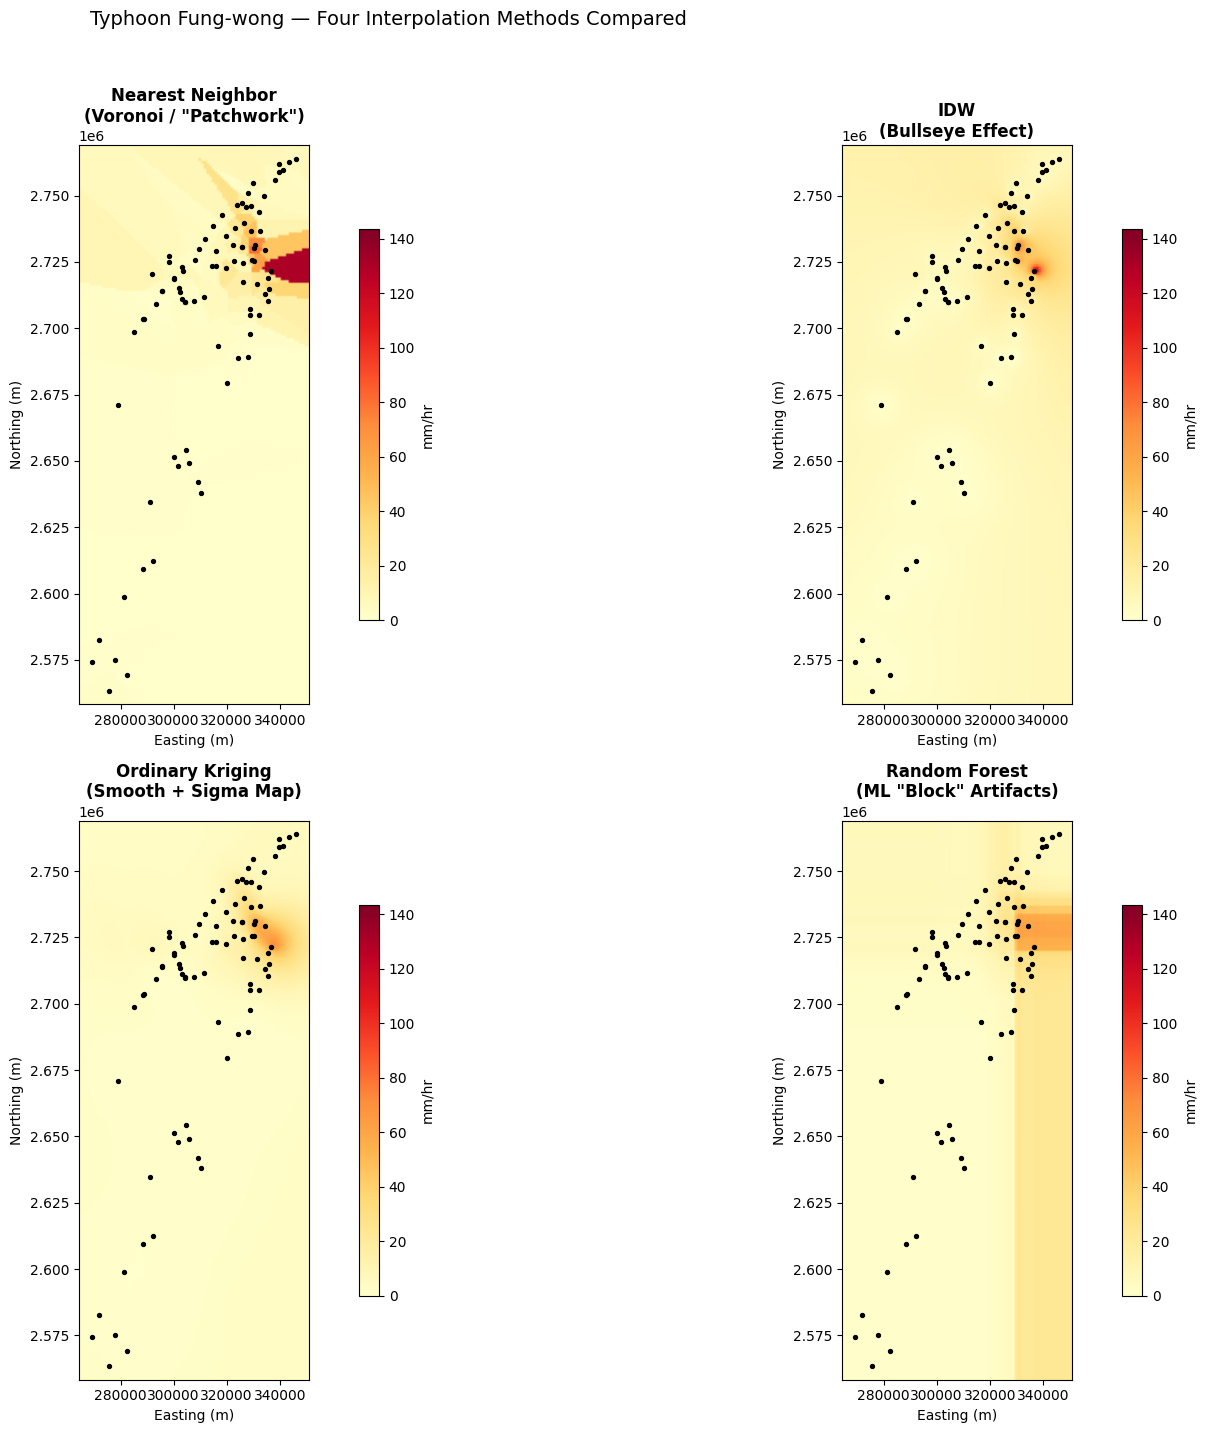

In [15]:
# YOUR CODE HERE:
# 1. Create fig, axes = plt.subplots(2, 2, figsize=(18, 14))
# 2. Plot all four methods with imshow
# 3. Use extent=[x_min, x_max, y_min, y_max], origin='lower'
# 4. Overlay station scatter points
# 5. Add colorbars, titles, save figure

# vmax = max(z) * 1.1
# methods = [
#     ('Nearest Neighbor\n(Voronoi / "Patchwork")', z_nn),
#     ('IDW\n(Bullseye Effect)', z_idw),
#     ('Ordinary Kriging\n(Smooth + Sigma Map)', z_kriging),
#     ('Random Forest\n(ML "Block" Artifacts)', z_rf),
# ]

# for ax, (title, data) in zip(axes.flatten(), methods):
#     im = ax.imshow(data, extent=[x_min, x_max, y_min, y_max],
#                    origin='lower', cmap='YlOrRd', vmin=0, vmax=vmax)
#     ax.scatter(x, y, c='black', s=8, zorder=5)
#     ax.set_title(title, fontsize=12, fontweight='bold')
#     plt.colorbar(im, ax=ax, shrink=0.7, label='mm/hr')

# plt.suptitle('Typhoon Fung-wong — Four Interpolation Methods Compared', fontsize=14, y=1.02)
# plt.tight_layout()
# plt.savefig('interpolation_shootout.png', dpi=150, bbox_inches='tight')
# plt.show()

# 1. Create fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 2. Prepare plotting settings
vmax = max(z) * 1.1
methods = [
    ('Nearest Neighbor\n(Voronoi / "Patchwork")', z_nn),
    ('IDW\n(Bullseye Effect)', z_idw),
    ('Ordinary Kriging\n(Smooth + Sigma Map)', z_kriging),
    ('Random Forest\n(ML "Block" Artifacts)', z_rf),
]

# 3. Plot all four methods with imshow
for ax, (title, data) in zip(axes.flatten(), methods):
    im = ax.imshow(
        data,
        extent=[x_min, x_max, y_min, y_max],
        origin='lower',
        cmap='YlOrRd',
        vmin=0,
        vmax=vmax
    )

    # 4. Overlay station scatter points
    ax.scatter(x, y, c='black', s=8, zorder=5)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')

    # 5. Add colorbar
    plt.colorbar(im, ax=ax, shrink=0.7, label='mm/hr')

plt.suptitle('Typhoon Fung-wong — Four Interpolation Methods Compared', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('interpolation_shootout.png', dpi=150, bbox_inches='tight')
plt.show()

### Cell [8]: Kriging vs RF — Direct Comparison

Create a 3-panel comparison: Kriging | Random Forest | Difference Map

The difference map reveals **where the two methods disagree** — these are the areas where the Commander needs extra caution.

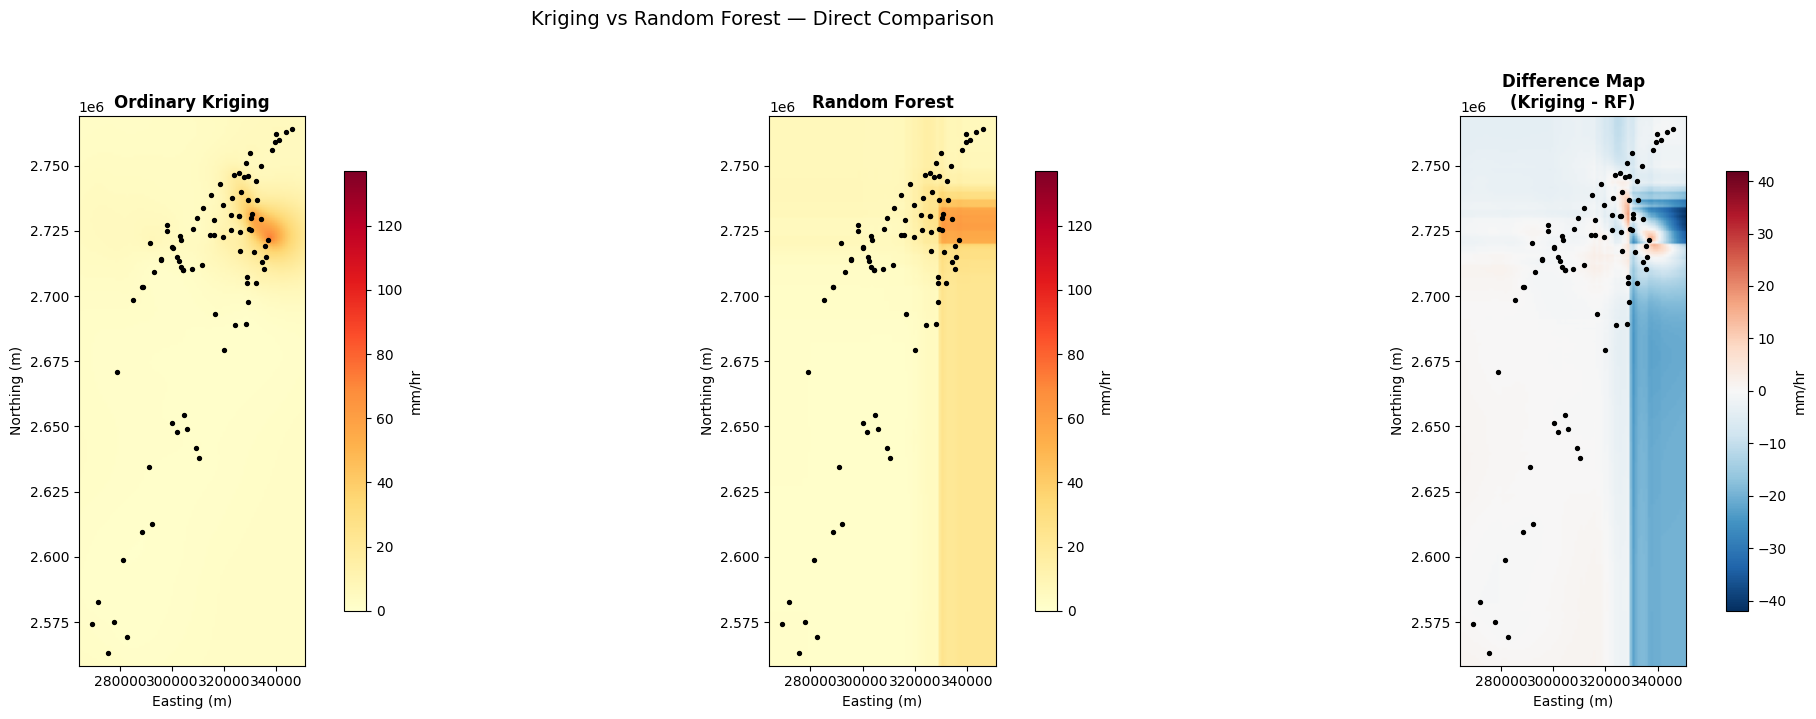

In [16]:
# YOUR CODE HERE:
# 1. Create fig, axes = plt.subplots(1, 3, figsize=(22, 7))
# 2. Left: Kriging (YlOrRd)
# 3. Middle: Random Forest (YlOrRd)
# 4. Right: Difference (Kriging - RF) using RdBu_r colormap
# 5. Save as 'kriging_vs_rf.png'

# diff = z_kriging - z_rf
# ...

# 1. Create fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Difference map
diff = z_kriging - z_rf

# Common max for rainfall maps
vmax = max(np.nanmax(z_kriging), np.nanmax(z_rf), np.nanmax(z)) * 1.05

# 2. Left: Kriging (YlOrRd)
im1 = axes[0].imshow(
    z_kriging,
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    cmap='YlOrRd',
    vmin=0,
    vmax=vmax
)
axes[0].scatter(x, y, c='black', s=8, zorder=5)
axes[0].set_title('Ordinary Kriging', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')
plt.colorbar(im1, ax=axes[0], shrink=0.8, label='mm/hr')

# 3. Middle: Random Forest (YlOrRd)
im2 = axes[1].imshow(
    z_rf,
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    cmap='YlOrRd',
    vmin=0,
    vmax=vmax
)
axes[1].scatter(x, y, c='black', s=8, zorder=5)
axes[1].set_title('Random Forest', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')
plt.colorbar(im2, ax=axes[1], shrink=0.8, label='mm/hr')

# 4. Right: Difference (Kriging - RF) using RdBu_r colormap
diff_absmax = np.nanmax(np.abs(diff))
im3 = axes[2].imshow(
    diff,
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    cmap='RdBu_r',
    vmin=-diff_absmax,
    vmax=diff_absmax
)
axes[2].scatter(x, y, c='black', s=8, zorder=5)
axes[2].set_title('Difference Map\n(Kriging - RF)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Easting (m)')
axes[2].set_ylabel('Northing (m)')
plt.colorbar(im3, ax=axes[2], shrink=0.8, label='mm/hr')

plt.suptitle('Kriging vs Random Forest — Direct Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('kriging_vs_rf.png', dpi=150, bbox_inches='tight')
plt.show()

### Lab 1 Reflection

**Questions to answer** (write in the cell below):

1. Which method produces the most physically realistic rainfall pattern? Why?
2. Where do Kriging and RF disagree the most? What does this tell you?
3. What "artifacts" do you observe in the NN and RF results?
4. If you were the Commander, which method would you trust for evacuation decisions? Why?

## Lab 1 Reflection

### 1. 哪一種方法產生的降雨分布最符合物理真實性？為什麼？

我認為在本次四種方法中，**Ordinary Kriging（普通克利金）** 所產生的降雨分布最具有物理真實性。

原因在於，降雨本質上是一種具有**空間自相關（spatial autocorrelation）**的自然現象，也就是說，距離較近的地點通常有較相似的降雨量，而距離較遠的地點，其降雨差異才會逐漸增加。Kriging 正是建立在這種空間相關性的統計假設之上，並透過 variogram 來描述「距離與差異程度之間的關係」，因此其結果通常會比單純依賴距離或機器學習位置切分的方式更符合真實降雨場應有的空間連續特性。

從圖面表現來看，Kriging 的結果通常具有以下幾個較合理的特徵：

- 降雨高值區與低值區之間呈現較自然、平滑的過渡，而不會突然跳變。
- 插值結果不只是複製單一測站值，而是根據周邊站點共同加權推估，因此較能反映整體降雨場的空間結構。
- 相較於 IDW 容易產生以測站為中心的同心圓效應，Kriging 的雨量分布更像連續的氣象場，而不是單純由每個站點向外擴散的影響範圍。

因此，若以「是否符合颱風降雨應呈現的連續空間分布」為判準，我認為 **Kriging 是最合理的結果**。

---

### 2. Kriging 與 Random Forest 在哪些地方差異最大？這代表什麼？

Kriging 與 Random Forest 的差異，通常會在以下幾類區域最明顯：

#### （1）測站較稀疏的區域
在距離測站較遠、觀測資料不足的地方，Kriging 與 RF 容易出現較大的差異。  
這是因為：

- **Kriging** 會根據整體空間相關結構進行平滑推估，因此在無站區域通常會呈現較保守、較連續的估計值。
- **Random Forest** 則是根據訓練資料中的座標模式進行切分與預測，它並不真正理解空間連續性，因此在資料稀疏區可能會產生較不穩定或不自然的區塊式預測。

#### （2）高降雨梯度區域
在高值區與低值區交界處，也就是雨量變化很快的區域，兩者差異也往往較大。  
原因是：

- Kriging 傾向保留整體趨勢，但會受到周圍點共同影響，因此有時會把極端值稍微平滑化。
- RF 可能因樹模型切分規則而在局部直接給出較突兀的高值或低值，造成與 Kriging 有明顯差異。

#### （3）邊界區域
研究區外圍或靠近資料範圍邊緣的位置，也常是差異較大的地方。  
因為邊界附近缺乏完整的四周鄰近資訊，Kriging 在這些區域的推估本來就比較不穩，而 RF 在外推時也可能受限於訓練資料分布。

這代表的意義是：

> **當兩種方法在某些區域差異很大時，表示這些地方的預測結果具有較高的不確定性，不能只看單一模型的結果就直接下判斷。**

換句話說，這些區域就是決策者需要特別提高警覺的地方。若這是真實災害應變情境，這類區域可能需要：

- 補設測站
- 參考更多地形、風向、雷達等資料
- 或優先派員現地確認

---

### 3. 在 Nearest Neighbor 與 Random Forest 的結果中，你觀察到哪些「人工痕跡（artifacts）」？

#### （1）Nearest Neighbor（NN）的人工痕跡
Nearest Neighbor 的主要特徵是非常明顯的**拼布狀 / Voronoi 區塊感**。  
它的問題在於每個格點都直接複製最近測站的值，因此會出現：

- 區域邊界非常銳利，像被硬切開一樣
- 同一塊區域內數值完全一樣，缺乏自然變化
- 雨量在邊界處突然跳變，沒有任何平滑過渡

這種結果雖然計算快速，也能保留測站原始值，但對於降雨這種本來應該平滑變化的現象而言，**太過粗糙且不符合物理直覺**。

#### （2）Random Forest（RF）的人工痕跡
Random Forest 的結果則常出現一種**方塊狀 / 階梯狀 / Minecraft 式區塊感**。  
這是因為 RF 是由多棵決策樹組成，而決策樹本質上是對特徵空間做閾值切分，例如：

- 如果 easting > 某值，走左邊
- 如果 northing < 某值，走右邊

因此最後畫成空間圖時，常會看到：

- 沿 X 或 Y 方向切出的塊狀區域
- 不夠圓滑的空間邊界
- 某些區域內值變化不連續，呈現機械式分段

雖然 RF 在訓練資料上可能表現很好，甚至訓練 R² 很高，但這不代表它在空間連續面的視覺與物理解釋上就一定合理。特別是在只用座標當特徵時，RF 很容易只是「記住測站位置的模式」，而不是真正學到降雨形成機制。

---

### 4. 如果你是指揮官（Commander），你會相信哪一種方法來做疏散決策？為什麼？

如果我是指揮官，在本次四種方法中，我會**優先相信 Kriging**，而不是單獨依賴 NN、IDW 或 Random Forest。

原因如下：

#### （1）Kriging 的空間邏輯最符合降雨現象
Kriging 明確利用測站之間的空間相關性來推估未知位置，因此它不是單純複製最近站值，也不是純粹用演算法分割座標空間，而是以統計方式建立「距離—相似性」的關係。對於降雨這類空間現象，這樣的邏輯最具說服力。

#### （2）Kriging 的結果較平滑、較自然
在災害應變中，若一張降雨圖出現大量不自然的鋸齒狀、區塊狀或拼布狀分布，會降低決策者對圖面的信任。Kriging 的結果通常較接近真實天氣場的空間樣貌，因此更適合作為風險判斷基礎。

#### （3）Kriging 還能提供不確定性資訊
雖然這一題主要是比較雨量圖，但 Kriging 後續還可以產生 **Sigma Map / Variance Map**，這是它相較於 RF 非常重要的優勢。  
對指揮官而言，最重要的不只是「哪裡雨大」，還包括：

- 哪裡的預測值得相信？
- 哪裡雖然看起來雨大，但其實不確定性也高？

這種「誠實呈現不確定性」的能力，對避難決策非常重要。

#### （4）其他方法較適合作為輔助比較，而非主要依據
- **NN**：太粗糙，只適合快速 baseline，不適合作為正式疏散依據。
- **IDW**：雖比 NN 平滑，但容易出現 bullseye effect，對極端值與測站分布很敏感。
- **RF**：雖然彈性高，也適合加入更多變數，但若目前只用座標作為輸入，結果容易出現 block artifacts，且沒有不確定性圖，因此單獨用來做高風險決策較不放心。

因此，我的結論是：

> **若要進行疏散決策，我最信任 Kriging，因為它在空間結構、物理合理性與決策可解釋性上都比其他方法更有優勢。**

但若是實務應用，我不會只看單一方法，而是會：

- 以 **Kriging 作為主模型**
- 搭配 **RF / IDW 做交叉比對**
- 再結合 **Kriging 的不確定性圖** 一起判讀

這樣才能做出更穩健的防災判斷。

---

## ⏸️ Lab 2: Confidence & Uncertainty Diagnosis (30 min)

### Cell [9]: The Sigma Map — Kriging's Unique Weapon (Slide 15)

**Captain's Log**: This is what makes Kriging special. No other method natively provides a confidence map.

- `ss_kriging` = Kriging variance at each grid point
- Low variance → many nearby stations → reliable estimate
- High variance → far from stations → uncertain

**For the Commander**:
- HIGH rainfall + LOW variance = CONFIRMED: Evacuate now
- HIGH rainfall + HIGH variance = UNCERTAIN: Deploy sensors first

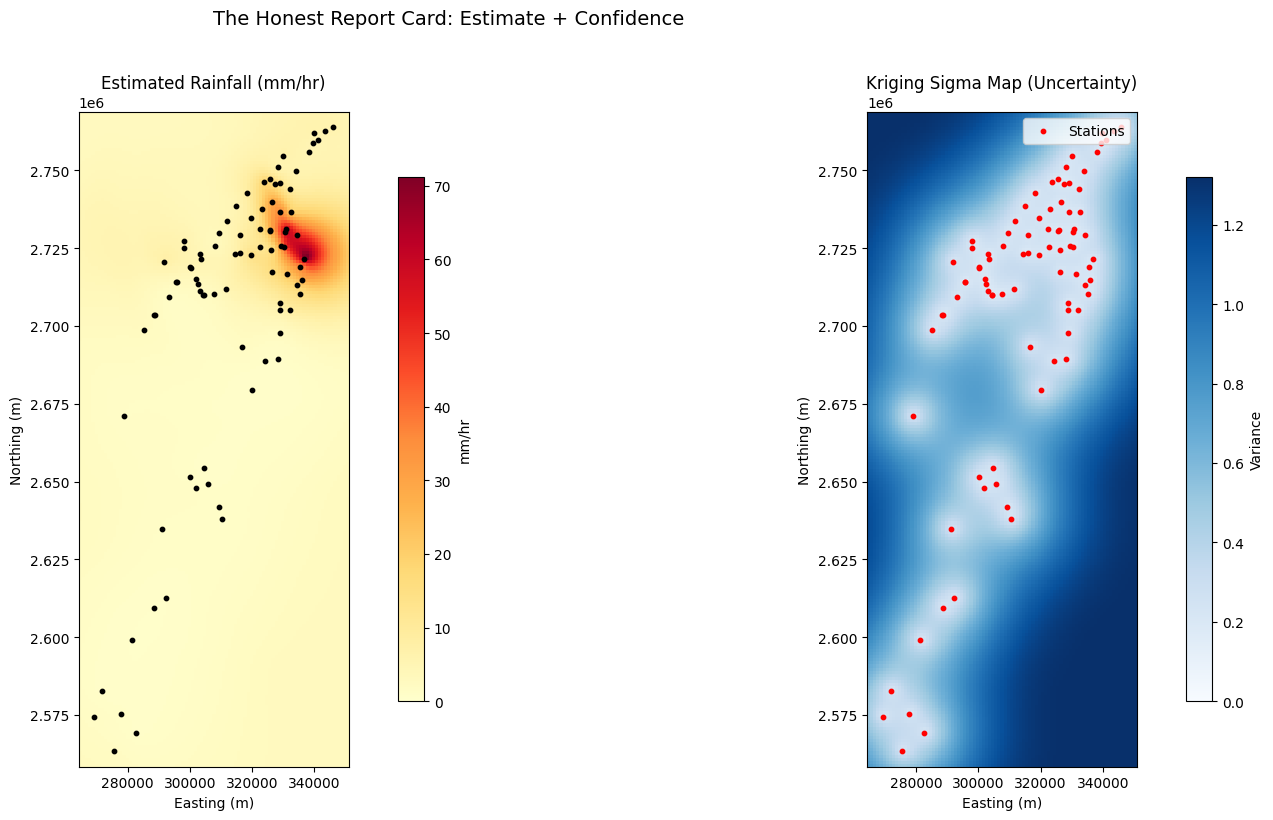

Variance range: 0.2 - 1.3


In [17]:
# YOUR CODE HERE:
# Create a 2-panel figure:
# Left: z_kriging with YlOrRd colormap (rainfall estimate)
# Right: ss_kriging with Blues colormap (variance/uncertainty)
# Add station locations on both panels (red dots on variance map)
# Save as 'sigma_map.png'

# fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# # Rainfall estimate
# im1 = axes[0].imshow(z_kriging, extent=[x_min, x_max, y_min, y_max],
#                       origin='lower', cmap='YlOrRd', vmin=0)
# axes[0].scatter(x, y, c='black', s=10, zorder=5)
# axes[0].set_title('Estimated Rainfall (mm/hr)')
# plt.colorbar(im1, ax=axes[0], shrink=0.8, label='mm/hr')

# # Kriging Variance (Sigma Map)
# im2 = axes[1].imshow(ss_kriging, extent=[x_min, x_max, y_min, y_max],
#                       origin='lower', cmap='Blues', vmin=0)
# axes[1].scatter(x, y, c='red', s=10, zorder=5, label='Stations')
# axes[1].set_title('Kriging Sigma Map (Uncertainty)')
# axes[1].legend(loc='upper right')
# plt.colorbar(im2, ax=axes[1], shrink=0.8, label='Variance')

# plt.suptitle('The Honest Report Card: Estimate + Confidence', fontsize=14, y=1.02)
# plt.tight_layout()
# plt.savefig('sigma_map.png', dpi=150, bbox_inches='tight')
# plt.show()

# print(f"Variance range: {np.nanmin(ss_kriging):.1f} - {np.nanmax(ss_kriging):.1f}")

# Create a 2-panel figure:
# Left: z_kriging with YlOrRd colormap (rainfall estimate)
# Right: ss_kriging with Blues colormap (variance/uncertainty)
# Add station locations on both panels (red dots on variance map)
# Save as 'sigma_map.png'

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Rainfall estimate
im1 = axes[0].imshow(
    z_kriging,
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    cmap='YlOrRd',
    vmin=0
)
axes[0].scatter(x, y, c='black', s=10, zorder=5)
axes[0].set_title('Estimated Rainfall (mm/hr)')
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')
plt.colorbar(im1, ax=axes[0], shrink=0.8, label='mm/hr')

# Kriging Variance (Sigma Map)
im2 = axes[1].imshow(
    ss_kriging,
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    cmap='Blues',
    vmin=0
)
axes[1].scatter(x, y, c='red', s=10, zorder=5, label='Stations')
axes[1].set_title('Kriging Sigma Map (Uncertainty)')
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')
axes[1].legend(loc='upper right')
plt.colorbar(im2, ax=axes[1], shrink=0.8, label='Variance')

plt.suptitle('The Honest Report Card: Estimate + Confidence', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('sigma_map.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Variance range: {np.nanmin(ss_kriging):.1f} - {np.nanmax(ss_kriging):.1f}")

### Cell [9b]: Nugget Effect — Why Extreme Rain Gets Diluted (Slide 7)

Suao recorded **130.5 mm/hr**, but default Kriging predicts only ~71 mm at 500m away. Why?

**Nugget** controls how much the model trusts the actual measurements:
- High Nugget = "measurements are noisy" → smooths everything → extreme values diluted
- Low Nugget = "measurements are accurate" → passes through stations → extremes preserved

**Task**: Compare Nugget=10% vs Nugget=1% on a zoomed-in map around Suao. Which preserves the extreme rainfall better?

**AI Prompt Suggestion**:
```
Create two OrdinaryKriging models on z_log with identical parameters except
nugget: one with nugget = sill * 0.10, one with nugget = sill * 0.01.
Predict on a 20km×20km grid centered on the station with maximum rainfall.
Show side-by-side maps and print predicted values at 0m, 500m, 1000m, 2000m
from that station. Which Nugget preserves the extreme value better?
```

Station with max rainfall: 蘇澳 = 130.5 mm/hr


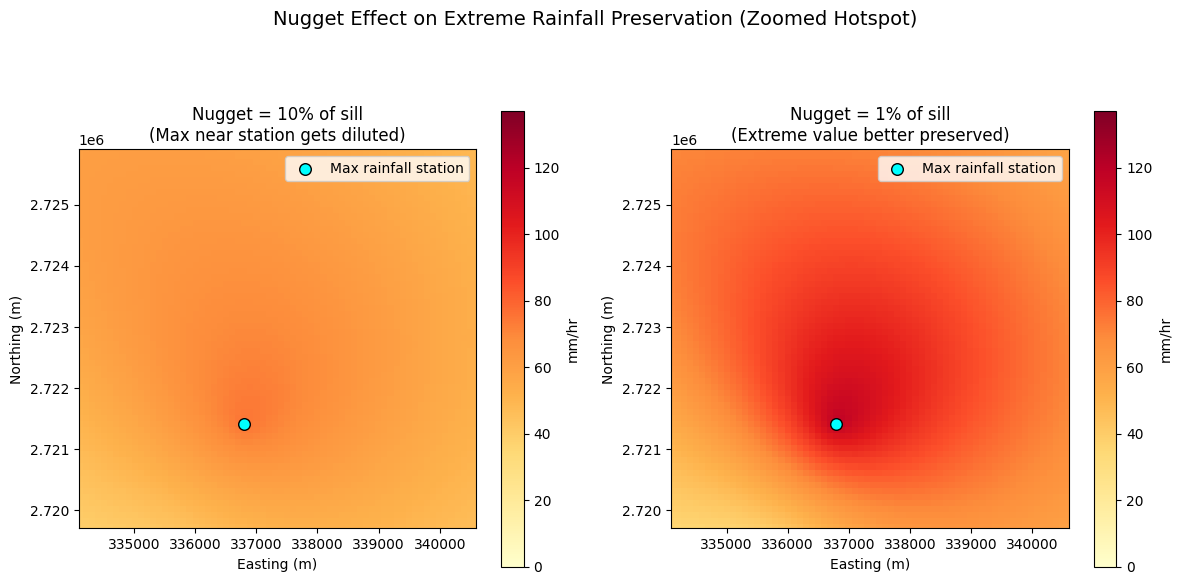


Predicted rainfall at offsets from max-rainfall station:


,offset_m,nugget_10pct_mmhr,nugget_1pct_mmhr
0,0,130.50,130.50
1,500,70.88,107.32
2,1000,67.27,98.83
3,2000,60.96,85.71



Observed station rainfall at center point: 130.5 mm/hr
Compare how fast each Nugget setting dilutes the extreme rainfall as distance increases.
Usually, Nugget = 1% preserves the extreme value better than Nugget = 10%.

🔑 Which Nugget setting is better for CWA calibrated stations? Why?
For calibrated CWA stations, a LOWER Nugget is usually better.
Reason: it assumes the station measurements are more trustworthy,
so Kriging preserves observed extremes better instead of over-smoothing them.


In [25]:
# YOUR CODE HERE:
# 1. Find the station with maximum rainfall (suao_idx = np.argmax(z))
# 2. Create two OrdinaryKriging models: nugget = sill*0.10 and sill*0.01
# 3. Predict on a local grid (20km box) around that station
# 4. Plot side-by-side comparison maps
# 5. Predict at specific offsets: 0m, 500m, 1000m, 2000m from the station
# 6. Print comparison table

# suao_idx = np.argmax(z)
# suao_x, suao_y, suao_z = x[suao_idx], y[suao_idx], z[suao_idx]
# print(f"Station with max rainfall: {suao_z:.1f} mm/hr")

# sill_val = float(z_log.var())
# ... create OK with nugget = sill_val * 0.10
# ... create OK with nugget = sill_val * 0.01
# ... compare predictions

# 🔑 Which Nugget setting is better for CWA calibrated stations? Why?


# 1. Find the station with maximum rainfall
suao_idx = np.argmax(z)
suao_x, suao_y, suao_z = x[suao_idx], y[suao_idx], z[suao_idx]

station_name = None
if "station_name" in study_rain_3826.columns:
    station_name = study_rain_3826.iloc[suao_idx]["station_name"]

if station_name is not None:
    print(f"Station with max rainfall: {station_name} = {suao_z:.1f} mm/hr")
else:
    print(f"Station with max rainfall: {suao_z:.1f} mm/hr")


# 2. Create two OrdinaryKriging models: nugget = sill*0.10 and sill*0.01
sill_val = float(z_log.var())
range_val = 50000.0

OK_nugget_10 = OrdinaryKriging(
    x, y, z_log,
    variogram_model='spherical',
    verbose=False,
    enable_plotting=False,
    nlags=15,
    variogram_parameters={
        'sill': sill_val,
        'range': range_val,
        'nugget': sill_val * 0.10
    }
)

OK_nugget_01 = OrdinaryKriging(
    x, y, z_log,
    variogram_model='spherical',
    verbose=False,
    enable_plotting=False,
    nlags=15,
    variogram_parameters={
        'sill': sill_val,
        'range': range_val,
        'nugget': sill_val * 0.01
    }
)


# 3. Predict on a local grid around that station
# 先用較大的範圍預測，再自動裁成只有高值紅色區域附近
local_half_size = 10000   # 先算 20km × 20km
local_res = 100           # 提高解析度，放大時較清楚

local_x = np.arange(suao_x - local_half_size, suao_x + local_half_size + local_res, local_res)
local_y = np.arange(suao_y - local_half_size, suao_y + local_half_size + local_res, local_res)

z_local_10_log, ss_local_10 = OK_nugget_10.execute('grid', local_x, local_y)
z_local_01_log, ss_local_01 = OK_nugget_01.execute('grid', local_x, local_y)

z_local_10 = np.expm1(z_local_10_log)
z_local_01 = np.expm1(z_local_01_log)

z_local_10 = np.asarray(z_local_10, dtype=float)
z_local_01 = np.asarray(z_local_01, dtype=float)

z_local_10[z_local_10 < 0] = 0
z_local_01[z_local_01 < 0] = 0


# 4. 自動找出「高雨量紅色區域」的範圍，讓圖只放大到那一塊
#    這裡用低 nugget 的結果來抓 hotspot，因為它保留極端值較好
threshold = suao_z * 0.60   # 可改成 0.5 或 0.7，數值越大，框得越緊
hot_mask = z_local_01 >= threshold

if np.any(hot_mask):
    hot_rows, hot_cols = np.where(hot_mask)

    x_hot_min = local_x[hot_cols.min()]
    x_hot_max = local_x[hot_cols.max()]
    y_hot_min = local_y[hot_rows.min()]
    y_hot_max = local_y[hot_rows.max()]

    pad = 800  # 額外留一些邊界，避免太擠
    zoom_x_min = x_hot_min - pad
    zoom_x_max = x_hot_max + pad
    zoom_y_min = y_hot_min - pad
    zoom_y_max = y_hot_max + pad
else:
    # 若沒有抓到 hotspot，就退回以最大站為中心的小範圍
    zoom_half = 2500
    zoom_x_min = suao_x - zoom_half
    zoom_x_max = suao_x + zoom_half
    zoom_y_min = suao_y - zoom_half
    zoom_y_max = suao_y + zoom_half


# 只保留 zoom 視窗內的測站，避免外圍黑點太多
station_mask = (
    (x >= zoom_x_min) & (x <= zoom_x_max) &
    (y >= zoom_y_min) & (y <= zoom_y_max)
)
x_zoom = x[station_mask]
y_zoom = y[station_mask]


# 5. Plot side-by-side comparison maps（只顯示紅色熱區附近）
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

vmax_local = max(np.nanmax(z_local_10), np.nanmax(z_local_01), suao_z) * 1.05
extent_local = [local_x.min(), local_x.max(), local_y.min(), local_y.max()]

im1 = axes[0].imshow(
    z_local_10,
    extent=extent_local,
    origin='lower',
    cmap='YlOrRd',
    vmin=0,
    vmax=vmax_local
)
axes[0].scatter(x_zoom, y_zoom, c='black', s=12, alpha=0.55, zorder=4)
axes[0].scatter(suao_x, suao_y, c='cyan', s=70, edgecolor='black', zorder=5, label='Max rainfall station')
axes[0].set_title('Nugget = 10% of sill\n(Max near station gets diluted)', fontsize=12)
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')
axes[0].set_xlim(zoom_x_min, zoom_x_max)
axes[0].set_ylim(zoom_y_min, zoom_y_max)
axes[0].legend(loc='upper right')
plt.colorbar(im1, ax=axes[0], shrink=0.85, label='mm/hr')

im2 = axes[1].imshow(
    z_local_01,
    extent=extent_local,
    origin='lower',
    cmap='YlOrRd',
    vmin=0,
    vmax=vmax_local
)
axes[1].scatter(x_zoom, y_zoom, c='black', s=12, alpha=0.55, zorder=4)
axes[1].scatter(suao_x, suao_y, c='cyan', s=70, edgecolor='black', zorder=5, label='Max rainfall station')
axes[1].set_title('Nugget = 1% of sill\n(Extreme value better preserved)', fontsize=12)
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')
axes[1].set_xlim(zoom_x_min, zoom_x_max)
axes[1].set_ylim(zoom_y_min, zoom_y_max)
axes[1].legend(loc='upper right')
plt.colorbar(im2, ax=axes[1], shrink=0.85, label='mm/hr')

plt.suptitle('Nugget Effect on Extreme Rainfall Preservation (Zoomed Hotspot)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# 6. Predict at specific offsets: 0m, 500m, 1000m, 2000m from the station
offsets_m = [0, 500, 1000, 2000]
compare_rows = []

for d in offsets_m:
    px = np.array([suao_x + d])
    py = np.array([suao_y])

    pred10_log, var10 = OK_nugget_10.execute('points', px, py)
    pred01_log, var01 = OK_nugget_01.execute('points', px, py)

    pred10 = float(np.expm1(pred10_log[0]))
    pred01 = float(np.expm1(pred01_log[0]))
    pred10 = max(pred10, 0.0)
    pred01 = max(pred01, 0.0)

    compare_rows.append({
        "offset_m": d,
        "nugget_10pct_mmhr": pred10,
        "nugget_1pct_mmhr": pred01
    })

compare_df = pd.DataFrame(compare_rows)
print("\nPredicted rainfall at offsets from max-rainfall station:")
display(compare_df.style.format({
    "nugget_10pct_mmhr": "{:.2f}",
    "nugget_1pct_mmhr": "{:.2f}"
}))

print(f"\nObserved station rainfall at center point: {suao_z:.1f} mm/hr")
print("Compare how fast each Nugget setting dilutes the extreme rainfall as distance increases.")
print("Usually, Nugget = 1% preserves the extreme value better than Nugget = 10%.")

print("\n🔑 Which Nugget setting is better for CWA calibrated stations? Why?")
print("For calibrated CWA stations, a LOWER Nugget is usually better.")
print("Reason: it assumes the station measurements are more trustworthy,")
print("so Kriging preserves observed extremes better instead of over-smoothing them.")

### Cell [10]: Export to GeoTIFF (Slide 16)

⚠️ **Flip warning**: `z_kriging` row 0 = south (numpy convention). GeoTIFF row 0 = north. Use `np.flipud()` to fix.

**AI Prompt Suggestion**:
```
Save 2D numpy arrays as GeoTIFF using rasterio. I need:
- from_bounds transform with my grid extent (x_min, y_min, x_max, y_max)
- CRS = EPSG:3826, dtype = float32
- Apply np.flipud() before writing
- Save kriging_rainfall.tif, kriging_variance.tif, and rf_rainfall.tif
```

In [19]:
import rasterio
from rasterio.transform import from_bounds

# YOUR CODE HERE:
# 1. Compute rasterio transform using from_bounds
# 2. Write a helper function save_geotiff(data, filename)
# 3. Save kriging_rainfall.tif, kriging_variance.tif, rf_rainfall.tif
# Remember: np.flipud() before writing!

# transform = from_bounds(x_min, y_min, x_max, y_max,
#                         width=z_kriging.shape[1], height=z_kriging.shape[0])

# def save_geotiff(data, filename, crs='EPSG:3826'):
#     data_flipped = np.flipud(data).astype(np.float32)
#     with rasterio.open(filename, 'w', driver='GTiff',
#         height=data_flipped.shape[0], width=data_flipped.shape[1],
#         count=1, dtype='float32', crs=crs, transform=transform, nodata=-9999
#     ) as dst:
#         dst.write(data_flipped, 1)
#     print(f"✓ Saved {filename}")

# save_geotiff(z_kriging, 'kriging_rainfall.tif')
# save_geotiff(ss_kriging, 'kriging_variance.tif')
# save_geotiff(z_rf, 'rf_rainfall.tif')


import rasterio
from rasterio.transform import from_bounds

# 1. Compute rasterio transform using from_bounds
transform = from_bounds(
    x_min, y_min, x_max, y_max,
    width=z_kriging.shape[1],
    height=z_kriging.shape[0]
)

# 2. Write a helper function save_geotiff(data, filename)
def save_geotiff(data, filename, crs='EPSG:3826'):
    data_flipped = np.flipud(data).astype(np.float32)

    # 將非有限值改成 nodata
    data_flipped = np.where(np.isfinite(data_flipped), data_flipped, -9999).astype(np.float32)

    with rasterio.open(
        filename,
        'w',
        driver='GTiff',
        height=data_flipped.shape[0],
        width=data_flipped.shape[1],
        count=1,
        dtype='float32',
        crs=crs,
        transform=transform,
        nodata=-9999
    ) as dst:
        dst.write(data_flipped, 1)

    print(f"✓ Saved {filename}")

# 3. Save kriging_rainfall.tif, kriging_variance.tif, rf_rainfall.tif
# Remember: np.flipud() before writing!
save_geotiff(z_kriging, 'output/kriging_rainfall.tif')
save_geotiff(ss_kriging, 'output/kriging_variance.tif')
save_geotiff(z_rf, 'output/rf_rainfall.tif')

✓ Saved output/kriging_rainfall.tif
✓ Saved output/kriging_variance.tif
✓ Saved output/rf_rainfall.tif


### Cell [11]: Zonal Statistics — Township Decision Table

Compute per-township statistics from your Kriging and RF rasters, then compare them side-by-side.

**Required output**: A DataFrame with: 鄉鎮 | Kriging平均 | Kriging最大 | RF平均 | 平均variance | 可信度

In [22]:
from rasterstats import zonal_stats

# YOUR CODE HERE:
# 1. Load township boundaries (TGOS shapefile)
# 2. Filter to 花蓮縣 + 宜蘭縣, convert to EPSG:3826
# 3. Run zonal_stats on kriging_rainfall.tif, kriging_variance.tif, rf_rainfall.tif
# 4. Create summary DataFrame with columns:
#    鄉鎮, 縣市, Kriging平均, Kriging最大, RF平均, 平均variance
# 5. Add 可信度 column:
#    HIGH: variance < 33rd percentile
#    MEDIUM: 33rd-66th percentile
#    LOW: > 66th percentile

# Note: If you don't have the township shapefile, skip this cell
# and describe what the expected output would be in the markdown below.

# try:
#     towns = gpd.read_file('path/to/TOWN_MOI.shp')
#     study_towns = towns[towns['COUNTYNAME'].isin(['花蓮縣', '宜蘭縣'])].copy()
#     study_towns = study_towns.to_crs(epsg=3826)
#     ... (compute zonal stats and create summary table)
# except Exception as e:
#     print(f"Township shapefile not found: {e}")

from rasterstats import zonal_stats

# 1. Load township boundaries (TGOS shapefile)
#    請把 shp_path 改成你實際的 shp 路徑
shp_path = "data/TOWN_MOI_1140318.shp"

try:
    towns = gpd.read_file(shp_path)

    # 2. Filter to 花蓮縣 + 宜蘭縣, convert to EPSG:3826
    study_towns = towns[towns["COUNTYNAME"].isin(["花蓮縣", "宜蘭縣"])].copy()
    study_towns = study_towns.to_crs(epsg=3826)

    # 3. Run zonal_stats on kriging_rainfall.tif, kriging_variance.tif, rf_rainfall.tif
    zs_kriging = zonal_stats(
        study_towns,
        "output/kriging_rainfall.tif",
        stats=["mean", "max"],
        nodata=-9999
    )

    zs_variance = zonal_stats(
        study_towns,
        "output/kriging_variance.tif",
        stats=["mean"],
        nodata=-9999
    )

    zs_rf = zonal_stats(
        study_towns,
        "output/rf_rainfall.tif",
        stats=["mean"],
        nodata=-9999
    )

    # 4. Create summary DataFrame
    summary_df = study_towns[["TOWNNAME", "COUNTYNAME"]].copy()
    summary_df = summary_df.rename(columns={
        "TOWNNAME": "鄉鎮",
        "COUNTYNAME": "縣市"
    })

    summary_df["Kriging平均"] = [d["mean"] for d in zs_kriging]
    summary_df["Kriging最大"] = [d["max"] for d in zs_kriging]
    summary_df["RF平均"] = [d["mean"] for d in zs_rf]
    summary_df["平均variance"] = [d["mean"] for d in zs_variance]

    # 5. Add 可信度 column
    q33 = summary_df["平均variance"].quantile(0.33)
    q66 = summary_df["平均variance"].quantile(0.66)

    def classify_confidence(v):
        if pd.isna(v):
            return np.nan
        elif v < q33:
            return "HIGH"
        elif v < q66:
            return "MEDIUM"
        else:
            return "LOW"

    summary_df["可信度"] = summary_df["平均variance"].apply(classify_confidence)

    # 數值格式整理
    numeric_cols = ["Kriging平均", "Kriging最大", "RF平均", "平均variance"]
    summary_df[numeric_cols] = summary_df[numeric_cols].round(2)

    # 依 Kriging 平均降雨由大到小排序
    summary_df = summary_df.sort_values(
        by=["Kriging平均", "Kriging最大"],
        ascending=False
    ).reset_index(drop=True)

    display(summary_df)

except Exception as e:
    print(f"Township shapefile not found or failed to process: {e}")



,鄉鎮,縣市,Kriging平均,Kriging最大,RF平均,平均variance,可信度
0,五結鄉,宜蘭縣,46.20,60.17,51.66,0.23,HIGH
1,羅東鎮,宜蘭縣,38.75,57.86,31.32,0.21,HIGH
2,蘇澳鎮,宜蘭縣,37.08,71.19,39.19,0.24,HIGH
3,冬山鄉,宜蘭縣,28.31,59.73,32.81,0.22,HIGH
4,宜蘭市,宜蘭縣,28.19,35.34,23.94,0.23,HIGH
5,壯圍鄉,宜蘭縣,23.58,38.92,31.80,0.23,HIGH
6,礁溪鄉,宜蘭縣,13.36,23.58,14.97,0.24,HIGH
7,三星鄉,宜蘭縣,9.41,31.84,11.04,0.24,HIGH
8,員山鄉,宜蘭縣,8.69,24.49,10.67,0.26,MEDIUM
9,頭城鎮,宜蘭縣,5.77,8.68,9.14,0.25,MEDIUM


### Cell [12]: Thinking Challenge — Why Can't ML Give You a Sigma Map?

**Discussion Questions** (answer in the cell below):

1. Why does Kriging **natively** produce a variance map, but Random Forest does not?
2. Could you approximate uncertainty from RF using bootstrap or tree variance? What are the limitations?
3. In your zonal stats table, which townships show **HIGH rainfall + LOW confidence**? What should the Commander do about those?

<div style="font-size: 13px; line-height: 1.7;">

## Lab 2 Reflection

### 1. 為什麼 Kriging 可以**原生（natively）**產生 variance map，而 Random Forest 不行？

Kriging 之所以可以原生產生變異數地圖（variance map 或 sigma map），是因為它本質上不是單純的插值工具，而是一種**明確建立在空間統計理論上的最佳線性無偏估計法（Best Linear Unbiased Estimator, BLUE）**。  
它在進行預測時，不只會估計某一位置的預測值，也會同時計算該預測值的**估計誤差變異數（estimation variance）**。

其核心原因如下：

#### （1）Kriging 先假設空間自相關結構
Kriging 不是只看點的位置，而是先透過 variogram 去描述：

- 距離越近的測站，觀測值通常越相似
- 距離越遠，相關性逐漸下降
- 當距離超過某個 range 後，彼此幾乎不再提供有效資訊

因此，Kriging 在每一個預測位置上，都能根據：
- 周圍有多少測站
- 測站距離有多近
- 空間自相關有多強
- nugget / sill / range 的設定

來計算「這個位置的預測到底有多可靠」。

換言之，**Kriging 的 variance map 是模型數學推導的一部分，不是額外附加的功能**。

#### （2）Kriging 的 uncertainty 和空間配置直接連動
Kriging variance 會自然反映測站幾何分布：

- 測站密集區 → variance 較低
- 離測站很遠的區域 → variance 較高
- 位在邊界或測站空洞區的地方 → variance 通常偏高

這種不確定性不是來自「模型亂猜」，而是來自「目前觀測網路對該位置支撐程度不足」。

相對地，Random Forest 並不具備這種原生 uncertainty map，原因在於：

#### （3）Random Forest 是監督式機器學習模型，不是空間統計模型
RF 的任務是學習：

\[
f(\text{easting}, \text{northing}) \rightarrow \text{rainfall}
\]

它只是在找一個能把輸入特徵映射到輸出結果的非線性函數。  
它並不會顯式建模：

- 測站之間的空間共變異
- 預測誤差的解析解
- 某位置受哪些鄰近觀測支撐

因此 RF 最終輸出的通常只是：
- 一個預測值

而不是：
- 一個預測值 + 一個對應的空間統計誤差變異數

#### （4）RF 不知道自己「離資料多遠」
Kriging 會知道某個位置距離最近測站有多遠，因此可以合理地說「這裡不確定性高」。  
但 RF 即便也使用座標作為輸入，它並不會自然產生「距離資料支持範圍有多遠」這種可解釋的不確定性量化。

所以總結而言：

> **Kriging 的 variance map 是空間統計模型內建的結果；Random Forest 則只是預測器，本身沒有空間誤差結構的解析解，因此不能原生提供 sigma map。**

---

### 2. 可不可以用 bootstrap 或 tree variance 來近似 RF 的不確定性？有什麼限制？

理論上是可以的，**但那只是近似的不確定性（approximate uncertainty）**，而不是像 Kriging 那樣有明確空間統計意義的 variance map。

常見做法有兩種：

#### （1）Bootstrap / Bagging-based uncertainty
可以對訓練資料進行多次重抽樣（bootstrap resampling），每次重新訓練一個 RF，然後對同一個 grid 位置重複預測。  
這樣就可以得到：

- 平均預測值
- 多次預測之間的標準差或變異數

如果某個位置多次模型預測差異很大，就可視為「模型在此較不穩定」。

**優點**
- 容易理解
- 容易實作
- 可以得到某種分散程度指標

**限制**
- 這個變異反映的是**模型對抽樣變動的敏感度**，不等於真實的空間預測誤差
- 如果資料本身非常稀疏，即使 bootstrap 變異不大，也不代表那個位置真的可靠
- 計算成本高，因為需要重複訓練多次模型

#### （2）Tree variance / Ensemble spread
Random Forest 本身由很多棵樹組成，因此也可以針對每一個 grid 點，收集每棵樹的預測值，再計算：

- 樹之間的平均
- 樹之間的標準差

若各棵樹預測差異很大，可視為該位置不確定性較高。

**優點**
- 不必額外重訓太多模型
- 可直接利用森林內部的多棵樹結果

**限制**
- 各棵樹並非完全獨立，tree spread 不一定真能代表 epistemic uncertainty
- 它比較像「模型內部意見分歧」，不是空間統計上的 kriging variance
- 在外插區域，RF 有時仍可能給出看似穩定但其實不可信的結果
- 無法直接告訴你「因為離測站遠，所以不確定性高」

#### （3）更根本的限制：RF uncertainty 缺乏空間可解釋性
即使你用 bootstrap 或 tree variance 做出一張「不確定性圖」，它和 Kriging 的 sigma map 還是有本質差異：

- **Kriging variance**：來自空間自相關模型與觀測幾何結構，可直接解釋成「資料支撐程度」
- **RF uncertainty approximation**：多半只是模型穩定度或模型分歧度的 proxy，不一定能反映實際空間推估誤差

所以這些方法可以當作輔助診斷，但不能完全取代 Kriging 的 sigma map。

總結來說：

> **RF 可以用 bootstrap 或 tree variance 近似不確定性，但那通常只是模型層級的近似指標，不是像 Kriging 一樣具備嚴謹空間統計意義的 confidence map。**

---

### 3. 在你的 zonal stats 表中，哪些鄉鎮呈現「高雨量 + 低可信度」？指揮官應該怎麼做？

這一題的核心不是只看「雨量高」，而是要同時看：

- **Kriging平均 / Kriging最大 是否偏高**
- **平均 variance 是否偏高**
- 因而判斷該鄉鎮的 **可信度是否 LOW**

換句話說，「高雨量 + 低可信度」代表：

> 這些鄉鎮看起來可能很危險，但目前監測網對該區的支撐不足，因此這個風險判斷仍具有顯著不確定性。

#### （1）你應該如何從表中找出這些鄉鎮
可優先鎖定同時符合以下條件的行政區：

- `Kriging平均` 或 `Kriging最大` 位於所有鄉鎮中的較高值
- `平均variance` 位於高分位
- `可信度 = LOW`

這些就是所謂的 **HIGH rainfall + LOW confidence** 區域。

通常這類鄉鎮常出現在：
- 測站之間距離較遠的地方
- 山區或邊界地帶
- 雨量高值區附近但觀測支撐不夠完整的位置

如果你的 study area 是花蓮、宜蘭，這類區域很可能出現在：
- 山區鄉鎮
- 海岸與山地交界帶
- 測站較少覆蓋的行政區

但**具體是哪幾個鄉鎮，仍應以你在 Cell [11] 產出的 summary DataFrame 為準**，因為那是依你實際計算結果得到的。

#### （2）指揮官不能怎麼做
對於「高雨量 + 低可信度」的鄉鎮，指揮官**不能只因為模型顯示高雨量就完全相信，也不能因為不確定就什麼都不做**。  
這種區域最危險的地方就在於：

- 它可能真的很危險
- 但目前資料又不足以高信心確認

所以這是典型的**需要補充資訊的高風險不確定區**。

#### （3）指揮官應該怎麼做
我認為比較合理的決策策略是：

**① 優先補強監測**
- 部署臨時雨量計
- 檢查鄰近自動站是否失效
- 納入雷達回波、衛星雲雨資料、上游集水區資訊

**② 提升警戒層級，但保留彈性**
- 將該鄉鎮列為「重點監控區」
- 提前通知地方政府與防災單位待命
- 啟動預警，但不一定立刻下達最強制的全面撤離命令

**③ 若區域本身屬高脆弱環境，應偏保守決策**
例如：
- 山區聚落
- 土石流潛勢溪流附近
- 易淹水低窪地
- 交通中斷風險高的地區

即使 confidence 低，只要 rainfall 預測高、脆弱度又高，仍應採取較保守的應變措施。

#### （4）決策意義
因此，「高雨量 + 低可信度」並不是叫指揮官忽略它，反而是要把它當成：

> **最需要額外注意、補充資訊與快速現地驗證的區域。**

也就是說：

- **高雨量 + 高可信度** → 可以更直接下達疏散或強制應變
- **高雨量 + 低可信度** → 應快速增派感測、交叉驗證、優先監控，必要時採保守預警

---

## 總結

本次 Lab 2 顯示出 Kriging 最大的優勢，不只是能估計雨量分布，而是能進一步告訴我們「哪裡的估計值得信任、哪裡的估計還不夠穩」。這一點對災害防救特別重要，因為防災決策不能只依賴一張看似漂亮的預測圖，而必須同時考慮**預測值本身**與**預測背後的不確定性**。

因此，若我是指揮官，我不會只問「哪裡雨最大」，而會進一步問：

- 哪裡雨大而且可信？
- 哪裡雨大但其實還很不確定？
- 哪些地方需要先派更多感測器或現場巡查？

這正是 Sigma Map 的真正價值，也是為什麼在防災應用上，Kriging 往往比單純的機器學習預測更具有決策意義。

</div>

### Cell [13]: (Bonus) AI Advisor Consultation

Ask an AI model (Gemini, ChatGPT, or Claude):

> 「在花蓮山區，測站密度約 1 站 / 50 km²。我用 Kriging 和 Random Forest 分別做了降雨內插，結果在山區差異很大。Kriging 的 variance 在山區也很高。請問：(1) 我應該信哪個結果？(2) 如何改善山區的預測品質？」

Paste the AI's response below and write your own commentary.

### AI Response:

針對你描述的情境——**花蓮山區測站密度僅約 1 站 / 50 km²，Kriging 與 Random Forest 在山區內插結果差異很大，且 Kriging variance 也偏高**——我會這樣回答：

#### （1）我應該信哪個結果？

在這種情況下，**不建議直接單獨相信其中任何一個結果**，而應優先把 **Kriging 視為較誠實的風險提示工具**，把 **Random Forest 視為補充性的模式辨識結果**。

原因如下：

- **Kriging 的高 variance 本身就是重要訊號**，表示山區這些位置離測站較遠，或周圍測站配置不足，因此模型明確告訴你：「這裡我有在估，但我沒有很有把握。」這種資訊對防災判斷非常重要。
- **Random Forest 雖然也能產生連續面，但它不會自然告訴你哪裡不確定**。在山區這種地形劇烈變化、降雨受地形抬升與迎風背風效應強烈影響的環境下，如果 RF 只用座標去學習，可能只是學到平面位置的切分規則，而不是真正學到山區降雨機制。
- 當兩者在山區差異很大時，這通常代表：**資料不足、模型假設不足，或重要控制因子尚未被納入**。所以這不是「二選一」的問題，而是表示目前結果本身就具有顯著不確定性。

因此，若以實務決策角度來看：

- **若要判斷哪裡“可能有風險”**，可以先參考 Kriging，因為它至少會誠實標示高不確定區。
- **若要判斷哪裡“真的很可靠地高雨量”**，則應優先看「高雨量 + 低 variance」的區域。
- **對於高雨量但高 variance 的山區**，不能直接當成已確認事實，而應視為「高風險但尚待補強驗證」的區域。

換句話說：

> 在目前測站稀疏、模型結果分歧又大的情況下，我會**比較信 Kriging 對不確定性的揭露**，但不會把 Kriging 的數值本身直接當成絕對真值；同時我也不會直接相信 RF 的表面細節，因為那些細節可能只是模型切分造成的假象。

---

#### （2）如何改善山區的預測品質？

要改善山區降雨預測品質，關鍵不是只「換一個模型」，而是同時從 **資料、變數、方法、驗證** 四個方向一起加強。

---

##### A. 增加或補強觀測資料
這是最根本也最有效的方法。

因為花蓮山區測站密度僅約 1 站 / 50 km²，對山區降雨這種高度局部且受地形強烈控制的現象而言，這個密度通常偏低。若測站過少，即使模型再複雜，也只能在有限資訊下推估。

可行作法包括：

- 增設山區自動雨量站
- 臨時部署行動式感測器
- 檢查現有測站是否有缺測或品質不穩定問題
- 納入鄰近區域測站，擴大支撐範圍
- 結合雷達降雨估計資料，補足站點不足的空間盲區

如果可以結合雷達資料（例如 QPE / QPF），通常能大幅改善山區的空間覆蓋問題。

---

##### B. 不要只用座標，應加入山區降雨的控制因子
若 Random Forest 目前只使用 `[easting, northing]` 作為輸入，那它其實只是用平面座標去猜雨量，對山區而言通常不夠。

山區降雨常受到下列因素控制：

- **高程（elevation）**
- **坡度（slope）**
- **坡向（aspect）**
- **地形起伏度**
- **距山脊 / 距谷地距離**
- **迎風面 / 背風面位置**
- **與海岸距離**
- **風場資訊（若可取得）**
- **雷達反射率或衛星降雨指標**

若把這些特徵納入 RF 或其他 ML 模型，模型才有機會學到：
- 為什麼某些高海拔區雨量較高
- 為什麼某些迎風坡面降雨集中
- 為什麼某些谷地雖然位置接近，但雨量明顯不同

也就是說：

> **平面座標只能描述“在哪裡”，但地形與氣象變數才能描述“為什麼這裡下這麼多雨”。**

---

##### C. 考慮混合方法，而不是只做單一模型
在山區這種問題上，單一方法常常不夠。

你可以考慮以下幾種改進策略：

###### （1）Regression Kriging / Residual Kriging
先用地形與其他環境因子建立一個回歸或 RF 模型，捕捉大尺度趨勢；  
再對殘差進行 Kriging，補足空間自相關結構。

這種方法的優點是：

- 回歸部分處理「地形控制」
- Kriging 部分處理「空間殘差相關」

通常會比單純 Kriging 或單純 RF 更適合山區降雨。

###### （2）RF + spatial residual correction
先用 RF 做預測，再將 RF 殘差做空間插值修正，也是一種可行方式。

###### （3）Co-Kriging 或 External Drift Kriging
若你有其他與降雨高度相關的輔助變數（如高程、雷達降雨），可以考慮更進階的 Kriging 變形方法，把外部資訊納入。

---

##### D. 加強模型驗證，而不只看視覺效果
山區結果差很多時，不應只靠地圖看起來哪張比較順眼，而要做量化驗證。

建議至少做：

- **Leave-one-out cross validation（LOOCV）**
- **K-fold cross validation**
- 比較 RMSE、MAE、Bias、R²
- 特別檢查高雨量站的預測誤差
- 比較山區站與平地站的誤差是否有系統差異

若模型在整體 RMSE 看起來不錯，但在高海拔或極端降雨站誤差很大，那對防災應用仍然可能不夠好。

---

##### E. 決策上要區分「高值」與「高可信度高值」
在防災場景中，你最需要的不是一張單純的降雨圖，而是能區分：

- 哪裡真的高雨量而且可信
- 哪裡看起來高雨量，但其實很不確定

因此最實務的作法是把結果分成三類：

1. **高雨量 + 低 variance**  
   → 高信心危險區，可優先啟動應變或疏散

2. **高雨量 + 高 variance**  
   → 潛在危險區，但資料支撐不足，應優先補觀測或加強監控

3. **低雨量 + 高 variance**  
   → 目前看似安全，但不能過度放心，仍需注意資料不足造成的低估風險

這樣比只問「哪個模型比較對」更有決策價值。

---

### 結論

若 Kriging 與 Random Forest 在花蓮山區差異很大，而且 Kriging variance 又很高，我的建議是：

- **不要直接二選一相信某個模型**
- **優先相信 Kriging 對不確定性的揭露**
- **把高 variance 區視為資料不足的警示區**
- **改善預測的重點在於補資料、加地形與氣象特徵、採用混合方法、並做嚴格交叉驗證**

簡單說：

> **現在真正的問題不是“哪個模型比較厲害”，而是“目前的觀測與變數是否足以支撐對山區降雨做可靠預測”。**  
> 若答案是否定的，那最優先要做的，就是補足資料與物理控制因子，而不是只在兩張圖之間選邊站。

---

### My Commentary:

我同意上述建議，特別是「不能只選擇相信 Kriging 或 Random Forest 其中之一，而要先理解目前資料本身不足」這一點非常重要。對山區降雨而言，若測站稀疏、地形變化劇烈，則高 variance 本身就是有價值的警訊，因此後續確實應結合更多地形與氣象變數，甚至採用 regression kriging 或雷達資料，才能提升預測品質與決策可信度。

---

## ARIA Evolution Recap

| Version | Week | Capability | Key Question |
|---------|------|-----------|---------------|
| v1.0 | W3 | River buffer + shelters | How close to the river? |
| v2.0 | W4 | + DEM terrain analysis | How steep is the terrain? |
| v3.0 | W5 | + Real-time rainfall stations | How much rain RIGHT NOW? |
| **v3.5** | **W6** | **+ Kriging & ML interpolation** | **What about areas with NO station? How confident are we?** |
| v4.0 | Final Project | Your extension! | Your question! |

---

*"Interpolation is not just filling space; it is predicting risk where sensors cannot reach."*